# EDA по данным LMS Цифриум

Цель этого ноутбука — подготовить понятный и воспроизводимый аналитический слой для дальнейшего выбора целевого признака и обучения модели.

В этом ноутбуке мы **не пытаемся сразу построить финальный датасет любой ценой**. Вместо этого двигаемся поэтапно:

1. загружаем и выравниваем таблицы;
2. проверяем качество данных и ищем очевидные проблемы;
3. проводим черновую предобработку по каждой таблице отдельно;
4. строим только самые безопасные агрегаты и merge;
5. подготавливаем основу для проверки гипотез о более сложных связях между таблицами.

Базовая логика анализа:
- сначала техническая чистота данных;
- затем проверка корректности ключей и связей;
- только после этого — нетривиальные merge и построение сложных признаков.


Этот ноутбук задаёт видимый сквозной EDA- и feature-engineering пайплайн для кейса по аналитике LMS.

Проекту нужен один прозрачный аналитический артефакт, который начинается с сырых таблиц, проверяет логику сущностей, строит интерпретируемые блоки признаков и заканчивается master-таблицей, готовой для обучения.

Входные данные:
Сырые таблицы LMS из `data/raw`.

Ожидаемый результат:
Одна master-таблица признаков, где строго одна строка соответствует одному `users_course_id`, а также экспортированные промежуточные блоки, саммари и графики в `data/AGENT`.

# Инициализация путей и импортов

In [1]:
import gc
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Markdown, display, HTML


def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "scripts").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Project root with scripts/ and data/ was not found.")


PROJECT_ROOT = resolve_project_root()
os.environ["PYTHONIOENCODING"] = "utf-8"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for module_name in list(sys.modules):
    if module_name == "scripts" or module_name.startswith("scripts."):
        sys.modules.pop(module_name, None)

from scripts.agg_feat_engineering_AGENT import (
    build_access_history_features,
    build_course_action_features,
    build_course_structure_features,
    build_media_features,
    build_stats_module_features,
    build_time_window_features,
    build_user_answer_features,
    build_user_lesson_features,
    build_user_training_features,
    build_users_base_features,
    build_users_courses_base,
)
from scripts.config_AGENT import BLOCK_EXPORT_NAMES, CORE_ENTITY_KEY, FIGURES_DIR, TABLES_DIR
from scripts.merge_AGENT import assemble_master_user_course_table
from scripts.service_AGENT import (
    build_direct_link_diagnostics,
    build_key_diagnostics,
    build_missingness_summary,
    build_route_coverage,
    describe_loaded_table,
    drop_service_columns,
    ensure_output_directories,
    load_all_tables,
    normalize_id_columns,
    save_dataframe,
    save_summary,
)

def display_scrollable_dataframe(df: pd.DataFrame, height: str = "420px"):
    display(
        HTML(
            f"""
            <div style="max-height: {height}; overflow-y: auto; border: 1px solid #ddd; padding: 4px;">
                {df.to_html(index=False, escape=False)}
            </div>
            """
        )
    )

display(Markdown("### Resolved project root"))
display(pd.DataFrame({"project_root": [str(PROJECT_ROOT)]}))

plt.style.use("ggplot")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)


def savefig(file_name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / file_name, dpi=160, bbox_inches="tight")


def summary_frame(summary: dict) -> pd.DataFrame:
    return pd.DataFrame([summary])


ensure_output_directories()

### Resolved project root

,project_root
0,C:\Repos\Xakaton


# 1. Черновая предобработка

- выполняется первичный аудит сырого датасета и текущей логики загрузки таблиц;
- проверяется полнота подключённых источников и выявляются пропущенные, но содержательно важные таблицы;
- фиксируются базовые характеристики таблиц: размерности, ключевые идентификаторы, временные поля, предполагаемый grain;
- проводится черновая проверка структуры данных, типов столбцов и общего профиля пропусков;
- формируется надёжная основа для следующего этапа: содержательной предобработки, очистки и проверки связей между таблицами.

## 1.1 Загрузка таблиц

In [ ]:
table_names = [
    "users_courses",
    "users",
    "lessons",
    "lesson_tasks",
    "trainings",
    "user_lessons",
    "user_trainings",
    "user_answers",
    "wk_users_courses_actions",
    "wk_media_view_sessions",
    "user_access_histories",
    "user_award_badges",
    "award_badges",
    "groups",
    "homeworks",
    "homework_items",
    "stats__module_1",
    "stats__module_2",
    "stats__module_3",
    "stats__module_4",
]

dfs, tables_overview = load_all_tables(table_names)

display(Markdown("### Loaded tables overview"))
display(tables_overview)

Первичный аудит таблиц, здесь выводитися информация о колонках таблицы, колличестве пропусков в ней и о том, что считается ключем таблицы.

In [ ]:
for table_name in table_names:
    display(Markdown(f"### Таблица: `{table_name}`"))
    display(describe_loaded_table(table_name, dfs[table_name]))


### Таблица: `users_courses`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,object,0,0.0000,99,True,False
1,id,int64,0,0.0000,290835,True,False
2,user_id,object,0,0.0000,88319,True,False
3,wk_course_completed_at,datetime64[ns],290481,0.9988,353,False,True
4,wk_officially_started_at,datetime64[ns],193970,0.6669,136,False,True
5,wk_points,Float64,84910,0.2920,12800,False,False
6,wk_max_points,Float64,125,0.0004,77,False,False
7,wk_max_task_count,Float64,125,0.0004,81,False,False
8,wk_max_viewable_lessons,Float64,125,0.0004,25,False,False
9,access_finished_at,datetime64[ns],94,0.0003,460,False,True


### Таблица: `users`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,d_wk_municipal_id,object,31302,0.3281,1152,True,False
1,d_wk_region_id,object,31302,0.3281,202,True,False
2,d_wk_school_id,object,31302,0.3281,3219,True,False
3,grade_id,object,0,0.0000,13,True,False
4,id,int64,0,0.0000,95395,True,False
5,grade_changed_at,datetime64[ns],93591,0.9811,1646,False,True
6,wk_gender,category,79449,0.8328,2,False,False
7,timezone,category,178,0.0019,141,False,False
8,created_at,datetime64[ns],0,0.0000,65681,False,True
9,sign_in_count,object,0,0.0000,487,False,False


### Таблица: `lessons`

...

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,int64,0,0.000,2,True,False
1,parallel_id,int64,0,0.000,71,True,False
2,teacher_id,int64,0,0.000,36,True,False
3,user_id,int64,0,0.000,1955,True,False
4,interim_assessment_score,Float64,170,0.087,51,False,False
5,interim_assessment_submitted_at_msk,datetime64[ns],170,0.087,25,False,True
6,all_required_final_tasks_solved_flag,category,0,0.000,2,False,False
7,attended_live_lesson_flag,category,0,0.000,2,False,False
8,content_viewed_units,Float64,0,0.000,305,False,False
9,current_control_passed_flag,category,0,0.000,2,False,False


### Таблица: `stats__module_3`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,int64,0,0.0000,2,True,False
1,parallel_id,int64,0,0.0000,66,True,False
2,teacher_id,int64,0,0.0000,36,True,False
3,user_id,int64,0,0.0000,1785,True,False
4,interim_assessment_score,Float64,78,0.0437,62,False,False
5,interim_assessment_submitted_at_msk,datetime64[ns],78,0.0437,18,False,True
6,all_required_final_tasks_solved_flag,category,0,0.0000,2,False,False
7,attended_live_lesson_flag,category,0,0.0000,2,False,False
8,content_viewed_units,Float64,0,0.0000,276,False,False
9,current_control_passed_flag,category,0,0.0000,2,False,False


### Таблица: `stats__module_4`

,column_name,dtype,missing_count,missing_share,nunique,is_key_like,is_datetime_expected
0,course_id,float64,18,0.0105,2,True,False
1,parallel_id,float64,18,0.0105,63,True,False
2,teacher_id,float64,18,0.0105,33,True,False
3,user_id,int64,0,0.0000,1707,True,False
4,track_name,category,18,0.0105,2,False,False
5,all_required_final_tasks_solved_flag,category,0,0.0000,1,False,False
6,attended_live_lesson_flag,category,0,0.0000,2,False,False
7,content_viewed_units,Float64,0,0.0000,200,False,False
8,current_control_passed_flag,category,0,0.0000,1,False,False
9,final_assessment_passed_flag,category,0,0.0000,1,False,False


## 1.2 Аудит сырых данных и общий обзор

Аудит сырых данных показывает масштаб таблиц до применения любой логики объединения или агрегации.

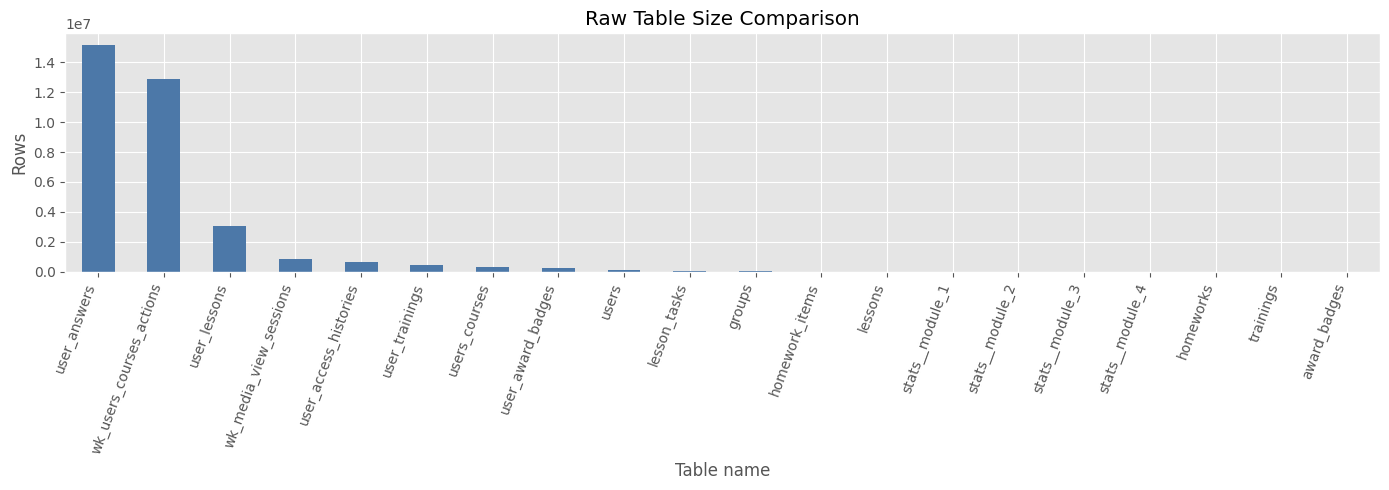

### Raw table size audit

,table_name,role,grain_guess,rows,cols,memory_mb,duplicate_full_rows,all_null_columns,mean_missing_share,max_missing_share,date_columns,key_like_columns,all_columns
0,user_answers,answer event log,user_id-level or user-event-level,15176182,12,3376.69,4950084,0,0.1141,0.6759,submitted_at,"user_id, task_id, resource_id","user_id, task_id, attempts, solved, points, max_attempts, skipped, resource_type, resource_id, submitted_at, wk_partial_answer, async_check_status"
1,wk_users_courses_actions,course activity event log,users_course_id-level / user-course,12909207,7,2278.05,5490050,0,0.2854,0.9988,"created_at, updated_at","user_id, users_course_id, sourceable_id, lesson_id","user_id, users_course_id, sourceable_id, action, created_at, updated_at, lesson_id"
2,user_lessons,user progress by lesson,users_course_id-level / user-course,3070664,10,653.78,0,0,0.0121,0.0603,,"user_id, lesson_id, users_course_id","user_id, lesson_id, video_visited, translation_visited, users_course_id, solved, solved_tasks_count, wk_points, video_viewed, wk_solved_task_count"
3,wk_media_view_sessions,media consumption event log,grain not inferred,852358,7,123.79,3558,0,0.0000,0.0000,started_at,"resource_id, viewer_id","resource_type, resource_id, viewer_id, segments_total, viewed_segments_count, started_at, kind"
4,user_access_histories,access history / administrative timeline,users_course_id-level / user-course,667124,4,15.91,355372,0,0.0000,0.0000,"access_started_at, access_expired_at",users_course_id,"users_course_id, access_started_at, access_expired_at, activator_class"
5,user_trainings,user progress by training,user_id-level or user-event-level,427628,12,78.73,0,0,0.0026,0.0078,"started_at, finished_at, mark_saved_at","user_id, training_id","user_id, training_id, solved_tasks_count, earned_points, type, state, submitted_answers_count, started_at, finished_at, attempts, mark, mark_saved_at"
6,users_courses,base enrollment / user-course registry,user_id + course_id-level,290835,13,58.15,0,0,0.1507,0.9988,"created_at, updated_at, access_finished_at, wk_officially_started_at, wk_course_completed_at","id, user_id, course_id","id, user_id, course_id, state, created_at, updated_at, access_finished_at, wk_points, wk_max_points, wk_max_viewable_lessons, wk_max_task_count, wk_officially_started_at, wk_course_completed_at"
7,user_award_badges,user achievements,user_id-level or user-event-level,252843,3,19.29,0,0,0.0000,0.0000,created_at,"award_badge_id, user_id","award_badge_id, user_id, created_at"
8,users,user profile / demographics,entity table with primary id,95395,13,29.01,0,0,0.2154,0.9811,"created_at, updated_at, grade_changed_at","id, grade_id, d_wk_school_id, d_wk_municipal_id, d_wk_region_id","id, created_at, updated_at, type, sign_in_count, grade_id, subscribed, timezone, grade_changed_at, d_wk_school_id, d_wk_municipal_id, d_wk_region_id, wk_gender"
9,lesson_tasks,lesson-task linkage,lesson_id-level,29544,5,4.12,0,0,0.0000,0.0000,,"id, lesson_id, task_id","id, lesson_id, task_id, position, task_required"


In [ ]:
raw_audit = tables_overview.sort_values("rows", ascending=False).reset_index(drop=True)
ax = raw_audit.plot.bar(x="table_name", y="rows", figsize=(14, 5), legend=False, color="#4C78A8")
ax.set_title("Raw Table Size Comparison")
ax.set_xlabel("Table name")
ax.set_ylabel("Rows")
plt.xticks(rotation=70, ha="right")
savefig("raw_table_size_comparison_AGENT.png")
plt.show()

display(Markdown("### Raw table size audit"))
display(raw_audit)

По результатам первичного аудита видно, что датасет включает таблицы существенно разного масштаба. Наибольший объём имеют событийные логи пользовательской активности, тогда как справочные и структурные таблицы заметно компактнее. Это подтверждает, что дальнейший EDA должен различать таблицы по их роли: одни описывают поток действий пользователей, другие — структуру курсов и агрегированные статусы прогресса. На текущем этапе мы получаем только общий обзор масштаба данных; для полноценного аудита далее требуется отдельно проверить ключи, пропуски, типы полей и согласованность grain между таблицами.

## 1.3 Проверка центральной сущности и прямых связей

На этом шаге мы определяем, какая сущность будет базовой для дальнейшего анализа и построения итоговой мастер-таблицы.  
Поскольку задача связана с прогнозированием поведения студента внутри конкретного курса, в качестве естественного уровня наблюдения рассматривается связка «пользователь–курс», представленная в таблице `users_courses`.

В рамках проверки решаются две подзадачи:
- оценивается, насколько устойчивы кандидатные ключи таблицы `users_courses`, прежде всего `id` и пара `(user_id, course_id)`;
- отдельно анализируются таблицы, которые уже содержат `users_course_id` напрямую и, следовательно, потенциально могут агрегироваться к целевому grain без сложного восстановления маршрутов связи.

Этот шаг необходим для того, чтобы до начала merge:
- зафиксировать корректный уровень агрегации;
- избежать размножения строк из-за неуникальных ключей;
- отделить таблицы с прямой привязкой к сущности `user-course` от таблиц, для которых связь ещё нужно восстанавливать через промежуточные объекты.

In [ ]:
entity_key_diagnostics = build_key_diagnostics(
    dfs["users_courses"],
    [["id"], ["user_id", "course_id"]],
)

direct_link_diagnostics = build_direct_link_diagnostics(
    dfs,
    [
        {"table_name": "user_lessons", "user_col": "user_id"},
        {"table_name": "wk_users_courses_actions", "user_col": "user_id"},
        {"table_name": "user_access_histories"},
    ],
)

stats_table_names = [table_name for table_name in table_names if table_name.startswith("stats__module_")]
stats_raw_key_frames = []
stats_raw_missing_frames = []

for table_name in stats_table_names:
    key_diag = build_key_diagnostics(dfs[table_name], [["user_id", "course_id"]]).copy()
    key_diag.insert(0, "table_name", table_name)
    key_diag["missing_key_rows"] = key_diag["rows"] - key_diag["non_null_rows"]
    key_diag["missing_key_share"] = key_diag["missing_key_rows"] / key_diag["rows"]
    stats_raw_key_frames.append(key_diag)

    missing_diag = build_missingness_summary(dfs[table_name]).head(8).copy()
    missing_diag.insert(0, "table_name", table_name)
    stats_raw_missing_frames.append(missing_diag)

stats_raw_key_diagnostics = pd.concat(stats_raw_key_frames, ignore_index=True)
stats_raw_missing_overview = pd.concat(stats_raw_missing_frames, ignore_index=True)

In [ ]:
display(Markdown("### Candidate key diagnostics for `users_courses`"))
display(
    entity_key_diagnostics.assign(
        missing_key_rows=lambda x: x["rows"] - x["non_null_rows"],
        missing_key_share=lambda x: (x["rows"] - x["non_null_rows"]) / x["rows"],
    )[
        [
            "key_cols",
            "rows",
            "non_null_rows",
            "missing_key_rows",
            "missing_key_share",
            "unique_key_rows",
            "duplicate_rows",
            "is_unique",
        ]
    ].style.format({
        "missing_key_share": "{:.2%}",
    })
)

display(Markdown("### Direct-link diagnostics for tables already carrying `users_course_id`"))
display(
    direct_link_diagnostics[
        [
            "table_name",
            "rows",
            "distinct_users_course_id",
            "missing_users_course_id",
            "missing_users_course_id_share",
            "users_per_users_course_gt_1",
        ]
    ].style.format({
        "missing_users_course_id_share": "{:.2%}",
    })
)

display(Markdown("### Raw key diagnostics for `stats__module_*` tables"))
display(
    stats_raw_key_diagnostics[
        [
            "table_name",
            "key_cols",
            "rows",
            "non_null_rows",
            "missing_key_rows",
            "missing_key_share",
            "unique_key_rows",
            "duplicate_rows",
            "is_unique",
        ]
    ].style.format({
        "missing_key_share": "{:.2%}",
    })
)

display(Markdown("### Missingness overview for `stats__module_*` tables"))
display(
    stats_raw_missing_overview.style.format({
        "missing_share": "{:.2%}",
    })
)

### Candidate key diagnostics for `users_courses`

,key_cols,rows,non_null_rows,missing_key_rows,missing_key_share,unique_key_rows,duplicate_rows,is_unique
0,['id'],290835,290835,0,0.00%,290835,0,True
1,"['user_id', 'course_id']",290835,290835,0,0.00%,290835,0,True


### Direct-link diagnostics for tables already carrying `users_course_id`

,table_name,rows,distinct_users_course_id,missing_users_course_id,missing_users_course_id_share,users_per_users_course_gt_1
0,user_lessons,3070664,216482,0,0.00%,0
1,wk_users_courses_actions,12909207,216342,0,0.00%,0
2,user_access_histories,667124,290784,0,0.00%,


### Raw key diagnostics for `stats__module_*` tables

,table_name,key_cols,rows,non_null_rows,missing_key_rows,missing_key_share,unique_key_rows,duplicate_rows,is_unique
0,stats__module_1,"['user_id', 'course_id']",3261,3200,61,1.87%,2972,228,False
1,stats__module_2,"['user_id', 'course_id']",1955,1955,0,0.00%,1955,0,True
2,stats__module_3,"['user_id', 'course_id']",1785,1785,0,0.00%,1785,0,True
3,stats__module_4,"['user_id', 'course_id']",1707,1689,18,1.05%,1689,0,True


### Missingness overview for `stats__module_*` tables

,table_name,column_name,missing_count,missing_share,dtype
0,stats__module_1,interim_assessment_score,1169,35.85%,Float64
1,stats__module_1,interim_assessment_submitted_at_msk,1169,35.85%,datetime64[ns]
2,stats__module_1,course_id,60,1.84%,float64
3,stats__module_1,parallel_id,60,1.84%,float64
4,stats__module_1,teacher_id,60,1.84%,float64
5,stats__module_1,track_name,60,1.84%,category
6,stats__module_1,user_id,44,1.35%,float64
7,stats__module_1,all_required_final_tasks_solved_flag,0,0.00%,category
8,stats__module_2,interim_assessment_score,170,8.70%,Float64
9,stats__module_2,interim_assessment_submitted_at_msk,170,8.70%,datetime64[ns]


Полученные диагностики позволяют проверить, можно ли использовать `users_course_id` как центральный идентификатор наблюдения.  
Если `users_courses.id` уникален, а в таблицах `user_lessons`, `wk_users_courses_actions` и `user_access_histories` этот ключ в основном заполнен и не конфликтует с `user_id`, то такие таблицы можно считать уже согласованными с целевым уровнем анализа.

Это означает, что часть блоков будущего EDA и feature engineering можно строить прямой агрегацией по `users_course_id`, не прибегая к сложным промежуточным merge.  
Именно такие таблицы образуют наиболее надёжное ядро для первой версии мастер-таблицы.

## 1.4 Техническая предобработка и нормализация идентификаторов

- нормализуются ID-подобные поля к единому числовому формату;
- фиксируются результаты нормализации: пропуски до и после приведения типов;
- удаляются заранее определённые служебные колонки, не используемые в анализе;
- определяется единый reference timestamp как правая временная граница наблюдений;
- формируется технически согласованный слой данных для дальнейших агрегаций и merge.

In [ ]:
dfs, id_cleaning_summary = normalize_id_columns(dfs)
dfs, drop_summary = drop_service_columns(dfs)

reference_timestamp = max(
    dfs['users_courses']['access_finished_at'].max(),
    dfs['users_courses']['created_at'].max(),
    dfs['users_courses']['wk_course_completed_at'].max(),
    dfs['users_courses']['wk_officially_started_at'].max(),
    dfs['user_access_histories']['access_expired_at'].max(),
    dfs['user_trainings']['finished_at'].max(),
    dfs['user_answers']['submitted_at'].max(),
    dfs['wk_users_courses_actions']['created_at'].max(),
    dfs['wk_media_view_sessions']['started_at'].max(),
)

block_summaries = []

display(Markdown("### Опорный момент времени"))
display(pd.DataFrame({"reference_timestamp": [reference_timestamp]}))

display(Markdown("### Сводка по нормализации ID-колонок"))
display(id_cleaning_summary)

display(Markdown("### Сводка по удалённым служебным колонкам"))
display(drop_summary)

### Опорный момент времени

,reference_timestamp
0,2026-09-27


### Сводка по нормализации ID-колонок

,table_name,column_name,missing_before,missing_after,dtype_after
0,users_courses,id,0,0,Int64
1,users_courses,user_id,0,0,Int64
2,users_courses,course_id,0,0,Int64
3,users,id,0,0,Int64
4,users,grade_id,0,0,Int64
5,users,d_wk_school_id,31302,31302,Int64
6,users,d_wk_municipal_id,31302,31302,Int64
7,users,d_wk_region_id,31302,31302,Int64
8,lessons,id,0,0,Int64
9,lessons,course_id,0,0,Int64


### Сводка по удалённым служебным колонкам

,table_name,dropped_columns,dropped_count
0,users_courses,,0
1,users,,0
2,lessons,,0
3,lesson_tasks,,0
4,trainings,,0
5,user_lessons,,0
6,user_trainings,,0
7,user_answers,,0
8,wk_users_courses_actions,,0
9,wk_media_view_sessions,,0


# 2 Базовая сущность `user-course`

- в качестве базового уровня наблюдения фиксируется связка «пользователь–курс»;
- таблица `users_courses` превращается в стартовую основу будущей master-table;
- идентификатор `id` переименовывается в `users_course_id` и используется как центральный ключ;
- из анализа исключаются записи, не относящиеся к ученикам;
- на уровне записи о прохождении курса строятся первые интерпретируемые признаки: статус доступа, наличие старта/завершения, базовые показатели прогресса и временные интервалы;
- дополнительно проверяется, что после фильтрации сохраняется уникальность одной строки на `users_course_id`.

In [ ]:


display(Markdown("### Типы пользователей в таблице `users`"))
user_type_counts = (
    dfs["users"]["type"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("type")
    .reset_index(name="rows")
)
display(user_type_counts)

### Типы пользователей в таблице `users`

,type,rows
0,User::Pupil,90647
1,User::Agent,4748


In [ ]:
users_courses_base_AGENT, users_courses_feature_list, users_courses_summary = build_users_courses_base(
    dfs['users_courses'],
    dfs['users'],
    reference_timestamp,
)

block_summaries.append(users_courses_summary)

display(Markdown("### Базовая таблица `users_courses_base_AGENT`"))

base_overview = pd.DataFrame({
    "metric": [
        "rows",
        "unique_users_course_id",
        "unique_user_id",
        "unique_course_id",
        "features_added",
    ],
    "value": [
        len(users_courses_base_AGENT),
        users_courses_base_AGENT[CORE_ENTITY_KEY].nunique(dropna=True),
        users_courses_base_AGENT["user_id"].nunique(dropna=True),
        users_courses_base_AGENT["course_id"].nunique(dropna=True),
        len(users_courses_feature_list),
    ],
})
display(base_overview)

display(Markdown("### Проверка ключей после построения базовой таблицы"))
base_key_diag = build_key_diagnostics(
    users_courses_base_AGENT,
    [[CORE_ENTITY_KEY], ["user_id", "course_id"]],
).copy()

base_key_diag["missing_key_rows"] = base_key_diag["rows"] - base_key_diag["non_null_rows"]
base_key_diag["missing_key_share"] = base_key_diag["missing_key_rows"] / base_key_diag["rows"]

display(
    base_key_diag[
        [
            "key_cols",
            "rows",
            "non_null_rows",
            "missing_key_rows",
            "missing_key_share",
            "unique_key_rows",
            "duplicate_rows",
            "is_unique",
        ]
    ].style.format({
        "missing_key_share": "{:.2%}",
    })
)

display(Markdown("### Первые признаки базовой сущности"))
display(Markdown("### Первые признаки базовой сущности"))

feature_meaning_map = {
    "uc_active_flag": "флаг активного доступа к курсу",
    "uc_has_official_start": "есть ли зафиксированный официальный старт курса",
    "uc_has_completion_record": "есть ли запись о завершении курса",
    "uc_has_access_end": "есть ли дата окончания доступа",
    "uc_points_ratio": "доля набранных баллов от максимально возможных",
    "uc_points_positive_flag": "есть ли хотя бы один набранный балл",
    "uc_full_points_flag": "набрал ли пользователь максимум баллов по курсу",
    "uc_tasks_per_viewable_lesson": "средняя плотность заданий на доступный урок",
    "uc_enrollment_age_days": "сколько дней прошло с момента создания записи о прохождении до reference timestamp",
    "uc_access_window_days": "длина окна доступа к курсу в днях",
    "uc_official_start_delay_days": "задержка между созданием записи и официальным стартом",
    "uc_completion_delay_days": "задержка между созданием записи и завершением курса",
    "uc_started_flag": "дублирующий удобный флаг того, что курс был начат",
    "uc_completed_flag": "дублирующий удобный флаг того, что курс был завершен",
    "uc_has_access_end_flag": "дублирующий удобный флаг наличия даты окончания доступа",
    "uc_has_points_flag": "есть ли ненулевая или непустая информация о набранных баллах",
    "uc_has_max_points_flag": "есть ли информация о максимально возможных баллах по курсу",
    "uc_has_viewable_lessons_flag": "есть ли информация о количестве доступных уроков",
    "uc_has_tasks_flag": "есть ли информация о количестве заданий в курсе",
    "uc_any_progress_flag": "есть ли хотя бы один признак реального прогресса: баллы, старт или завершение",
    "uc_points_per_task": "среднее количество баллов на одно задание курса",
    "uc_points_per_viewable_lesson": "среднее количество баллов на один доступный урок курса",
    "uc_viewable_lessons_per_task": "обратная плотность: сколько доступных уроков приходится на одно задание",
    "uc_completed_without_points_flag": "диагностический флаг: курс завершен, но баллы отсутствуют",
    "uc_started_without_points_flag": "диагностический флаг: курс начат, но баллы отсутствуют",
    "uc_has_points_without_start_flag": "диагностический флаг: баллы есть, но официальный старт не зафиксирован",
    "uc_start_anchor_at": "опорная дата старта для дальнейших временных признаков",
    "uc_days_from_anchor_to_access_end": "сколько дней прошло от опорной даты старта до окончания доступа",
    "uc_days_from_anchor_to_completion": "сколько дней прошло от опорной даты старта до завершения курса",
}

feature_meanings = pd.DataFrame({
    "feature": users_courses_feature_list,
    "meaning": [feature_meaning_map.get(feature, "описание пока не добавлено") for feature in users_courses_feature_list],
})

display(feature_meanings)

### Базовая таблица `users_courses_base_AGENT`

,metric,value
0,rows,267206
1,unique_users_course_id,267206
2,unique_user_id,84572
3,unique_course_id,82
4,features_added,29


### Проверка ключей после построения базовой таблицы

,key_cols,rows,non_null_rows,missing_key_rows,missing_key_share,unique_key_rows,duplicate_rows,is_unique
0,['users_course_id'],267206,267206,0,0.00%,267206,0,True
1,"['user_id', 'course_id']",267206,267206,0,0.00%,267206,0,True


### Первые признаки базовой сущности

### Первые признаки базовой сущности

,feature,meaning
0,uc_active_flag,флаг активного доступа к курсу
1,uc_has_official_start,есть ли зафиксированный официальный старт курса
2,uc_has_completion_record,есть ли запись о завершении курса
3,uc_has_access_end,есть ли дата окончания доступа
4,uc_points_ratio,доля набранных баллов от максимально возможных
5,uc_points_positive_flag,есть ли хотя бы один набранный балл
6,uc_full_points_flag,набрал ли пользователь максимум баллов по курсу
7,uc_tasks_per_viewable_lesson,средняя плотность заданий на доступный урок
8,uc_enrollment_age_days,сколько дней прошло с момента создания записи о прохождении до reference timestamp
9,uc_access_window_days,длина окна доступа к курсу в днях


## Краткое описание блока: `users_courses_base_AGENT`


- Таблицы‑источники: `users_courses`, `users`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: `users_courses.id -> users_course_id`, плюс фильтрация учеников через `users.id`
- Создаваемые признаки: `uc_*` признаки статуса доступа, завершения, доли баллов и базовые временные признаки
- Семантика признаков: блок фиксирует административное состояние записи «пользователь–курс» вместе с её непосредственным контекстом прогресса
- Путь слияния / агрегации: `users_courses + users -> фильтрация строк учеников -> расчёт базовых признаков сущности -> users_courses_base_AGENT`

После построения базовой таблицы в качестве центральной сущности анализа используется одна строка на `users_course_id`. Таблица `users_courses` служит стартовой основой для всей будущей master-table, поскольку именно она описывает прохождение конкретного курса конкретным пользователем и содержит административные поля доступа, начала, завершения и накопленных баллов.

На этом шаге из анализа исключаются записи, не относящиеся к ученикам, чтобы зафиксировать целевую популяцию задачи. В описании датасета указано, что в `users.type` различаются `Pupil` и `Agent`, то есть ученики и учителя. 

Дополнительно на уровне записи о прохождении курса строится первый набор интерпретируемых признаков:
- статус доступа к курсу;
- наличие старта, завершения и даты окончания доступа;
- базовые показатели прогресса по баллам;
- простые временные характеристики прохождения.

После этого отдельно проверяется, что базовая таблица сохраняет уникальность на уровне `users_course_id` и не нарушает целевой grain всей дальнейшей сборки. Такая проверка согласуется с общей логикой пайплайна Codex, где итоговая master-table собирается именно левыми merge от базовой таблицы user-course. 

# 3. Агрегация данных и построение признаков

В этом разделе сырые таблицы последовательно переводятся в интерпретируемые агрегаты, согласованные с целевым уровнем наблюдения `user-course`. 

Для каждого блока отдельно рассматриваются источник данных, логика маршрута до `users_course_id`, корректность агрегации и смысл получаемых признаков. 

Далее поэтапно разбираются все основные семейства признаков: пользовательские, курсные, прогресс по урокам, активность в тренингах, ответы на задания, действия в курсе, просмотр медиа и история доступа. Основная цель раздела — не просто собрать feature blocks, а показать, как именно каждый источник данных превращается в осмысленные и проверяемые характеристики поведения студента внутри курса.

## 3.1 Агрегация на уровне курса и расчёт признаков

Зачем нужен этот шаг:  
Перед тем как обогатить мастер‑таблицу «пользователь–курс», мы должны один раз агрегировать устойчивую структуру курса на уровне `course_id`.  
Это позволяет избежать повторного пересчёта одних и тех же метаданных курса для каждой строки `users_course_id` и даёт чистый структурный блок для последующих операций слияния.

Какую проблему решает:  
Этот блок проверяет, участвуют ли курсы из `users_courses_base_AGENT` в таблице `lessons`, а затем строит интерпретируемые структурные признаки на основе метаданных занятий, заданий, тренингов, вебинаров и домашних работ.  
Он разделяет свойства дизайна курса от поведения пользователей, что важно для последующей EDA и для чистой семантики признаков в итоговой мастер‑таблице.

Входные данные:
- `users_courses_base_AGENT` — базовый набор записей о зачисленных курсах
- `lessons`
- `lesson_tasks`
- `trainings`
- `groups`
- `homeworks`
- `homework_items`

Ожидаемый вывод:
- `course_hypothesis_table` с простой проверкой покрытия между записанными курсами и курсами, присутствующими в `lessons`
- `course_features_AGENT` с одной строкой на каждый `course_id`
- `course_feature_list` с набором сгенерированных структурных признаков
- `course_summary` с метаданными на уровне блока и ключевыми диагностиками

Как это помогает итоговой мастер‑таблице:  
Этот блок добавляет структурный контекст на уровне курса, который затем присоединяется к мастер‑таблице «пользователь–курс» по `course_id`.  
Эти признаки также переиспользуются в дальнейших шагах конвейера, например в `build_user_lesson_features`, где итоговые значения по курсу используются как знаменатели для долей прогресса пользователей.

Логика агрегации:
- `lessons` → агрегация по `course_id` → признаки структуры занятий  
- `lesson_tasks` + `lessons` → разрешение `course_id` → агрегация по `course_id` → признаки структуры заданий  
- `trainings` + `lessons` → разрешение `course_id` → агрегация по `course_id` → признаки структуры тренингов  
- `groups` + `lessons` → разрешение `course_id` → агрегация по `course_id` → признаки структуры вебинаров/групп  
- `homeworks` + `lessons` → разрешение `course_id` для привязанных к занятиям домашних работ → агрегация по `course_id` → признаки структуры домашних работ  
- `homework_items` + разрешённые домашние работы → агрегация по `course_id` → признаки структуры элементов домашних работ  
- все блоки на уровне курса → левое слияние по `course_id` → `course_features_AGENT`

Какие именно признаки создаются:
- объём занятий и состав занятий  
- объём заданий и плотность обязательных заданий  
- объём тренингов и средняя сложность тренинга  
- наличие и продолжительность вебинаров/групповых занятий  
- объём домашних работ и состав заданий в них  

In [ ]:
# -------------------------------------------------------------------------
# 3.1 Course-level aggregation and feature engineering
# -------------------------------------------------------------------------

base_course_ids = set(users_courses_base_AGENT["course_id"].dropna().unique().tolist())
lesson_course_ids = set(dfs["lessons"]["course_id"].dropna().unique().tolist())

course_hypothesis_table = pd.DataFrame([
    {
        "base_course_count": len(base_course_ids),
        "lessons_course_count": len(lesson_course_ids),
        "base_courses_missing_in_lessons": len(base_course_ids - lesson_course_ids),
        "lessons_only_courses": len(lesson_course_ids - base_course_ids),
        "base_course_coverage_by_lessons_share": (
            len(base_course_ids & lesson_course_ids) / len(base_course_ids)
            if len(base_course_ids) > 0 else pd.NA
        ),
        "lessons_overlap_with_base_share": (
            len(base_course_ids & lesson_course_ids) / len(lesson_course_ids)
            if len(lesson_course_ids) > 0 else pd.NA
        ),
    }
])

course_features_AGENT, course_feature_list, course_summary = build_course_structure_features(
    dfs["lessons"],
    dfs["lesson_tasks"],
    dfs["trainings"],
    dfs["groups"],
    dfs["homeworks"],
    dfs["homework_items"],
)
block_summaries.append(course_summary)

fig, ax = plt.subplots(figsize=(8, 4))
course_features_AGENT["course_lessons_count"].dropna().plot.hist(bins=20, ax=ax, color="#72B7B2")
ax.set_title("Distribution of Course Lesson Counts")
ax.set_xlabel("Lessons per course")
savefig("course_lessons_count_distribution_AGENT.png")
plt.show()

display(Markdown("### Проверка гипотезы покрытия курсов"))
display(
    course_hypothesis_table.style.format({
        "base_course_coverage_by_lessons_share": "{:.2%}",
        "lessons_overlap_with_base_share": "{:.2%}",
    })
)

display(Markdown("""
### Что делает блок `course_features_AGENT`

Этот блок агрегирует **структуру курса** на уровне `course_id`.

Используемые таблицы:
- `lessons` — основной каркас курса;
- `lesson_tasks` — связь уроков и задач;
- `trainings` — структура тренингов;
- `groups` — вебинары / онлайн-группы;
- `homeworks` и `homework_items` — структура домашних заданий.

Логика агрегации:
- `lessons -> aggregate by course_id`
- `lesson_tasks + lessons -> resolve course_id -> aggregate by course_id`
- `trainings + lessons -> resolve course_id -> aggregate by course_id`
- `groups + lessons -> resolve course_id -> aggregate by course_id`
- `homeworks[Lesson] + lessons -> resolve course_id -> aggregate by course_id`
- `homework_items + resolved homeworks -> aggregate by course_id`

Результат:
- одна строка на `course_id`;
- структурные признаки курса, которые потом можно безопасно мержить в master-таблицу по `course_id`.
"""))

display(Markdown("### Сводка по блоку `course_features_AGENT`"))
display(summary_frame(course_summary))

display(Markdown("### Проверка ключа `course_features_AGENT`"))
display(build_key_diagnostics(course_features_AGENT, [["course_id"]]))

if "extra" in course_summary and isinstance(course_summary["extra"], dict):
    coverage_rows = []
    for value in course_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)

    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации к `course_id`"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `course_features_AGENT`"))

course_feature_meaning_map = {
    "course_lessons_count": "общее число уроков в курсе",
    "course_lessons_with_tasks_count": "число уроков, в которых ожидаются задания",
    "course_lessons_with_conspect_count": "число уроков, в которых есть конспект",
    "course_lessons_survival_count": "число уроков с survival-тренажером",
    "course_lessons_scratch_count": "число уроков с Scratch-интеграцией",
    "course_lessons_attendance_count": "число уроков с включенным учетом посещаемости",
    "course_lesson_number_max": "максимальный номер урока в курсе",
    "course_lessons_max_points_sum": "суммарный максимум баллов по всем урокам курса",
    "course_lessons_task_count_sum": "суммарное число заданий по всем урокам курса",
    "course_video_duration_sum": "суммарная длительность видео по курсу",
    "course_video_duration_mean": "средняя длительность видео на урок",

    "course_lessons_with_tasks_share": "доля уроков, в которых есть задания",
    "course_lessons_with_conspect_share": "доля уроков, в которых есть конспект",
    "course_lessons_survival_share": "доля уроков с survival-тренажером",
    "course_lessons_scratch_share": "доля уроков с Scratch-интеграцией",
    "course_lessons_attendance_share": "доля уроков с учетом посещаемости",

    "course_tasks_per_lesson": "среднее число заданий на один урок",
    "course_points_per_lesson": "средний максимум баллов на один урок",
    "course_video_duration_per_lesson": "средняя длительность видео на один урок",
    "course_has_video_flag": "есть ли в курсе видео-контент",
    "course_lesson_number_gap": "разница между максимальным номером урока и фактическим числом уроков",

    "course_task_link_count": "общее число связей между уроками и задачами в курсе",
    "course_unique_task_count": "число уникальных задач курса",
    "course_required_task_count": "число обязательных задач курса",
    "course_required_task_share": "доля обязательных задач среди всех lesson-task связей",
    "course_unique_tasks_per_lesson": "среднее число уникальных задач на один урок",
    "course_required_tasks_per_lesson": "среднее число обязательных задач на один урок",
    "course_has_required_tasks_flag": "есть ли в курсе обязательные задачи",

    "course_trainings_count": "общее число тренингов курса",
    "course_training_task_templates_sum": "суммарное число шаблонов задач по тренингам курса",
    "course_training_difficulty_mean": "средняя сложность тренингов курса",
    "course_training_difficulty_max": "максимальная сложность тренинга в курсе",
    "course_trainings_per_lesson": "среднее число тренингов на один урок",
    "course_training_templates_per_training": "среднее число шаблонов задач на один тренинг",
    "course_has_trainings_flag": "есть ли в курсе тренинги",

    "course_groups_count": "общее число вебинаров / онлайн-групп курса",
    "course_groups_with_video_count": "число вебинаров, для которых доступна запись",
    "course_groups_duration_sum": "суммарная запланированная длительность вебинаров",
    "course_groups_actual_duration_sum": "суммарная фактическая длительность вебинаров",
    "course_groups_finished_count": "число вебинаров, завершившихся в состоянии `finished`",
    "course_groups_with_video_share": "доля вебинаров с доступной видеозаписью",
    "course_groups_finished_share": "доля завершенных вебинаров",
    "course_groups_per_lesson": "среднее число вебинаров на один урок",
    "course_group_actual_to_planned_duration_ratio": "отношение фактической суммарной длительности вебинаров к запланированной",
    "course_has_groups_flag": "есть ли в курсе вебинары / онлайн-группы",

    "course_homeworks_count": "число домашних заданий, привязанных к урокам курса",
    "course_unique_homework_types": "число уникальных типов домашних заданий в курсе",
    "course_homeworks_per_lesson": "среднее число домашних заданий на один урок",
    "course_has_homeworks_flag": "есть ли в курсе домашние задания",

    "course_homework_item_count": "общее число элементов внутри домашних заданий курса",
    "course_homework_task_item_count": "число элементов домашних заданий типа `Task`",
    "course_homework_items_per_homework": "среднее число элементов на одно домашнее задание",
    "course_homework_task_item_share": "доля элементов домашних заданий, которые являются задачами",
}

course_feature_meanings = pd.DataFrame({
    "feature": course_feature_list,
    "meaning": [course_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in course_feature_list],
})

display(course_feature_meanings)

AttributeError: 'IntegerArray' object has no attribute 'replace'

### Краткое описание блока: `course_features_AGENT`


- Таблицы‑источники: `lessons`, `lesson_tasks`, `trainings`, `groups`, `homeworks`, `homework_items`
- Уровень агрегации: `course_id`
- Ключи агрегации: агрегация структуры курса через `course_id`
- Создаваемые признаки: `course_*` признаки, связанные с объёмом занятий, плотностью заданий, плотностью тренингов, вебинарами/группами и структурой домашних работ
- Семантика признаков: блок описывает, насколько «тяжелым» и структурно богатым является каждый курс до учёта пользовательского поведения
- Путь слияния / агрегации: `lessons + связанные метаданные курса -> агрегация по course_id -> course_features_AGENT`

## 3.2 User-level aggregation

- Грейн: `user_id`
- Источники: `users`, `user_award_badges`, `award_badges`
- Что строим: профиль пользователя + агрегаты по наградам
- Куда пойдет: merge в master-таблицу по `user_id`

In [ ]:
user_features_AGENT, user_feature_list, user_summary = build_users_base_features(
    dfs["users"],
    dfs["user_award_badges"],
    dfs["award_badges"],
    reference_timestamp,
)
block_summaries.append(user_summary)

display(Markdown("### Блок `user_features_AGENT`"))

display(Markdown("""
Этот блок строит пользовательские признаки на уровне `user_id`.

Используемые таблицы:
- `users` — профиль и стабильные атрибуты пользователя;
- `user_award_badges` — факты присвоения наград;
- `award_badges` — словарь наград и их свойств.

Логика:
- из `users` оставляются только `User::Pupil`;
- по каждому `user_id` собираются базовые профильные признаки;
- история наград объединяется со справочником наград;
- затем награды агрегируются к одной строке на `user_id`;
- итоговый блок потом безопасно мержится в master-таблицу по `user_id`.

Важно:
- это user-level enrichment, а не course-specific behavior;
- признаки по наградам описывают платформенную активность и достижения пользователя в целом.
"""))

display(Markdown("### Сводка по блоку"))
display(summary_frame(user_summary))

display(Markdown("### Проверка ключа `user_features_AGENT`"))
display(build_key_diagnostics(user_features_AGENT, [["user_id"]]))

if "extra" in user_summary and isinstance(user_summary["extra"], dict):
    coverage_rows = []
    for value in user_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `user_features_AGENT`"))
user_feature_meaning_map = {
    # ---------------------------------------------------------------------
    # Raw user profile fields
    # ---------------------------------------------------------------------
    "sign_in_count": "общее число входов пользователя в LMS",
    "grade_id": "класс пользователя",
    "timezone": "таймзона пользователя",
    "wk_gender": "пол пользователя",
    "d_wk_region_id": "идентификатор региона пользователя",
    "d_wk_municipal_id": "идентификатор муниципалитета / города пользователя",
    "d_wk_school_id": "идентификатор школы пользователя",

    # ---------------------------------------------------------------------
    # Core profile flags and stable profile features
    # ---------------------------------------------------------------------
    "user_is_subscribed_flag": "подписан ли пользователь на рассылки платформы",
    "user_account_age_days": "сколько дней прошло с момента создания аккаунта до reference timestamp",
    "user_profile_age_days": "сколько дней прошло между созданием и последним обновлением профиля пользователя",
    "user_grade_change_delay_days": "сколько дней прошло от создания аккаунта до момента изменения класса",
    "user_has_grade_flag": "есть ли в профиле информация о классе пользователя",
    "user_has_timezone_flag": "есть ли в профиле информация о таймзоне",
    "user_has_region_flag": "есть ли в профиле информация о регионе",
    "user_has_municipal_flag": "есть ли в профиле информация о муниципалитете / городе",
    "user_has_school_flag": "есть ли в профиле информация о школе",
    "user_has_gender_flag": "есть ли в профиле информация о поле пользователя",

    # ---------------------------------------------------------------------
    # Badge aggregation features
    # ---------------------------------------------------------------------
    "user_badges_total_count": "общее число выданных пользователю наград",
    "user_badges_unique_count": "число уникальных типов наград пользователя",
    "user_special_badges_count": "число специальных наград пользователя",
    "user_badge_span_days": "сколько дней прошло между первой и последней полученной наградой",

    # ---------------------------------------------------------------------
    # Derived badge features
    # ---------------------------------------------------------------------
    "user_has_badges_flag": "есть ли у пользователя хотя бы одна награда",
    "user_has_special_badges_flag": "есть ли у пользователя хотя бы одна специальная награда",
    "user_first_badge_delay_days": "сколько дней прошло от создания аккаунта до первой награды",
    "user_badges_per_account_year": "среднее число наград в пересчете на один год жизни аккаунта",
    "user_unique_badges_per_account_year": "среднее число уникальных наград в пересчете на один год жизни аккаунта",

    # ---------------------------------------------------------------------
    # Auxiliary timestamps kept in the result for EDA
    # ---------------------------------------------------------------------
    "user_first_badge_at": "время первой награды пользователя",
    "user_last_badge_at": "время последней награды пользователя",
}

user_feature_meanings = pd.DataFrame({
    "feature": user_feature_list,
    "meaning": [user_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in user_feature_list],
})

display_scrollable_dataframe(user_feature_meanings, height="500px")

### Блок `user_features_AGENT`


Этот блок строит пользовательские признаки на уровне `user_id`.

Используемые таблицы:
- `users` — профиль и стабильные атрибуты пользователя;
- `user_award_badges` — факты присвоения наград;
- `award_badges` — словарь наград и их свойств.

Логика:
- из `users` оставляются только `User::Pupil`;
- по каждому `user_id` собираются базовые профильные признаки;
- история наград объединяется со справочником наград;
- затем награды агрегируются к одной строке на `user_id`;
- итоговый блок потом безопасно мержится в master-таблицу по `user_id`.

Важно:
- это user-level enrichment, а не course-specific behavior;
- признаки по наградам описывают платформенную активность и достижения пользователя в целом.


### Сводка по блоку

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings,badge_dictionary_route_coverage
0,users_base_features,"[users, user_award_badges, award_badges]",user_id,90647,27,[user_id],True,24,24,User-level features are aggregated to one row per user_id before joining to the user-course base table.,Badge-based signals are platform-wide and should be interpreted as enrichment rather than course-specific behavior.,"{'route_name': 'user_award_badges -> award_badges', 'rows_total': 252843, 'rows_matched': 252843, 'rows_unmatched': 0, 'coverage_ratio': 1.0}"


### Проверка ключа `user_features_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[user_id],90647,90647,90647,0,True


### Описание признаков `user_features_AGENT`

NameError: name 'HTML' is not defined

### Краткое описание блока: `user_features_AGENT`

- Таблицы‑источники: `users`, `user_award_badges`, `award_badges`
- Уровень агрегации: `user_id`
- Ключи агрегации: агрегация обогащения на уровне пользователя через `user_id`
- Создаваемые признаки: исходный профильный контекст плюс `user_*` признаки подписки, возраста, географии и истории значков
- Семантика признаков: блок даёт устойчивый контекст пользовательского профиля и истории взаимодействия с платформой, который можно переиспользовать для всех записей об обучении одного и того же ученика
- Путь слияния / агрегации: `users + user_award_badges + award_badges -> агрегация по user_id -> user_features_AGENT`

## 3.3 User-lesson aggregation

- Грейн: `users_course_id`
- Источники: `user_lessons`, `lessons`, `course_features_AGENT`
- Что строим: прогресс по урокам, просмотры, решенные уроки, ratio-признаки
- Куда пойдет: merge в master-таблицу по `users_course_id`

In [ ]:
user_lessons_agg_AGENT, user_lessons_feature_list, user_lessons_summary = build_user_lesson_features(
    dfs["user_lessons"],
    dfs["lessons"],
    course_features_AGENT,
)
block_summaries.append(user_lessons_summary)

display(Markdown("### Блок `user_lessons_agg_AGENT`"))

display(Markdown("""
Этот блок агрегирует прогресс пользователя по урокам на уровне `users_course_id`.

Используемые таблицы:
- `user_lessons` — пользовательские уроки и их прогресс;
- `lessons` — курс и порядок урока;
- `course_features_AGENT` — знаменатели для course-relative ratio-признаков.

Логика:
- `user_lessons` обогащается через `lessons`, чтобы получить `course_id` и `lesson_number`;
- затем все агрегируется к одной строке на `users_course_id`;
- после этого подтягиваются course-level знаменатели из `course_features_AGENT`;
- на финальном шаге строятся ratio-признаки относительно структуры курса и внутри самого lesson-блока.

Смысл:
- блок измеряет, сколько уроков пользователь реально затронул,
- насколько далеко продвинулся по курсу,
- сколько баллов и решенных задач накопил,
- как часто открывал видео и трансляции,
- и как этот прогресс выглядит относительно общей структуры курса.
"""))

display(Markdown("### Сводка по блоку"))
display(summary_frame(user_lessons_summary))

display(Markdown("### Проверка ключа `user_lessons_agg_AGENT`"))
display(build_key_diagnostics(user_lessons_agg_AGENT, [[CORE_ENTITY_KEY]]))

if "extra" in user_lessons_summary and isinstance(user_lessons_summary["extra"], dict):
    coverage_rows = []
    for value in user_lessons_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

    if "users_course_to_course_conflicts" in user_lessons_summary["extra"]:
        display(Markdown("### Диагностика конфликтов `users_course_id -> course_id`"))
        display(pd.DataFrame([{
            "metric": "users_course_to_course_conflicts",
            "value": user_lessons_summary["extra"]["users_course_to_course_conflicts"],
        }]))

display(Markdown("### Описание признаков `user_lessons_agg_AGENT`"))

user_lessons_feature_meaning_map = {
    # ---------------------------------------------------------------------
    # Core counts
    # ---------------------------------------------------------------------
    "ul_lessons_touched_count": "число уникальных уроков, которых пользователь коснулся в рамках курса",
    "ul_lessons_solved_count": "число уроков, по которым пользователь помечен как полностью решивший задания",
    "ul_video_visited_count": "число уроков, где пользователь открывал запись вебинара или видео",
    "ul_video_viewed_count": "число уроков, где пользователь помечен как просмотревший видео",
    "ul_translation_visited_count": "число уроков, где пользователь открывал онлайн-трансляцию",
    "ul_points_sum": "суммарные баллы пользователя по урокам курса",
    "ul_solved_tasks_sum": "суммарное число решенных задач по урокам с учетом fallback-логики между wk_solved_task_count и solved_tasks_count",
    "ul_furthest_lesson_number": "максимальный номер урока, до которого пользователь дошел в курсе",
    "ul_task_count_gap_sum": "суммарная разница между solved_tasks_count и wk_solved_task_count по урокам",

    # ---------------------------------------------------------------------
    # Normalized course-relative ratios
    # ---------------------------------------------------------------------
    "ul_lessons_touched_ratio": "доля затронутых уроков от общего числа уроков курса",
    "ul_furthest_lesson_ratio": "насколько далеко пользователь продвинулся по курсу относительно максимального номера урока",
    "ul_points_ratio_vs_course": "доля набранных пользователем баллов от суммарного максимума по урокам курса",
    "ul_solved_tasks_ratio_vs_course": "доля решенных пользователем задач от суммарного числа задач по урокам курса",

    # ---------------------------------------------------------------------
    # Within-block behavioral ratios
    # ---------------------------------------------------------------------
    "ul_lessons_solved_ratio": "доля полностью решенных уроков среди затронутых уроков",
    "ul_video_visited_ratio": "доля затронутых уроков, где пользователь открывал видео",
    "ul_video_viewed_ratio": "доля затронутых уроков, где пользователь просмотрел видео",
    "ul_translation_visited_ratio": "доля затронутых уроков, где пользователь открывал трансляцию",
    "ul_video_viewed_to_visited_ratio": "отношение числа просмотренных видео к числу посещений видео",
    "ul_points_per_touched_lesson": "среднее число баллов на один затронутый урок",
    "ul_solved_tasks_per_touched_lesson": "среднее число решенных задач на один затронутый урок",

    # ---------------------------------------------------------------------
    # Presence flags
    # ---------------------------------------------------------------------
    "ul_has_any_video_visit_flag": "есть ли хотя бы один урок, где пользователь открывал видео",
    "ul_has_any_video_view_flag": "есть ли хотя бы один урок, где пользователь просмотрел видео",
    "ul_has_any_translation_flag": "есть ли хотя бы один урок, где пользователь открывал трансляцию",
    "ul_has_any_solved_lesson_flag": "есть ли хотя бы один полностью решенный урок",
    "ul_course_mapping_conflict_flag": "есть ли конфликтное сопоставление одного users_course_id с несколькими course_id",
}

user_lessons_feature_meanings = pd.DataFrame({
    "feature": user_lessons_feature_list,
    "meaning": [user_lessons_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in user_lessons_feature_list],
})

display_scrollable_dataframe(user_lessons_feature_meanings)

del dfs["user_lessons"]
gc.collect()

### Блок `user_lessons_agg_AGENT`


Этот блок агрегирует прогресс пользователя по урокам на уровне `users_course_id`.

Используемые таблицы:
- `user_lessons` — пользовательские уроки и их прогресс;
- `lessons` — курс и порядок урока;
- `course_features_AGENT` — знаменатели для course-relative ratio-признаков.

Логика:
- `user_lessons` обогащается через `lessons`, чтобы получить `course_id` и `lesson_number`;
- затем все агрегируется к одной строке на `users_course_id`;
- после этого подтягиваются course-level знаменатели из `course_features_AGENT`;
- на финальном шаге строятся ratio-признаки относительно структуры курса и внутри самого lesson-блока.

Смысл:
- блок измеряет, сколько уроков пользователь реально затронул,
- насколько далеко продвинулся по курсу,
- сколько баллов и решенных задач накопил,
- как часто открывал видео и трансляции,
- и как этот прогресс выглядит относительно общей структуры курса.


### Сводка по блоку

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings
0,user_lesson_features,"[user_lessons, lessons, course_structure_features]",users_course_id,216482,21,[users_course_id],True,19,19,"Lesson progress is already keyed by users_course_id, so the aggregation is direct and low risk.",The solved task count keeps the resolved wk_solved_task_count fallback but also retains the aggregate gap signal for auditability.


### Проверка ключа `user_lessons_agg_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],216482,216482,216482,0,True


### Описание признаков `user_lessons_agg_AGENT`

,feature,meaning
0,ul_lesson_rows,"общее число строк user_lessons, попавших в агрегат по users_course_id"
1,ul_lessons_touched_count,"число уникальных уроков, которых пользователь коснулся в рамках курса"
2,ul_lessons_solved_count,"число уроков, по которым пользователь помечен как полностью решивший задания"
3,ul_video_visited_count,"число уроков, где пользователь открывал запись вебинара / видео"
4,ul_video_viewed_count,"число уроков, где пользователь помечен как просмотревший видео"
5,ul_translation_visited_count,"число уроков, где пользователь открывал онлайн-трансляцию"
6,ul_points_sum,суммарные баллы пользователя по урокам курса
7,ul_points_mean,среднее число баллов на одну строку user_lessons
8,ul_solved_tasks_sum,суммарное число решенных задач по урокам с учетом fallback-логики между wk_solved_task_count и solved_tasks_count
9,ul_furthest_lesson_number,"максимальный номер урока, до которого пользователь дошел в курсе"


0

### Краткое описание блока: `user_lessons_agg_AGENT`


- Таблицы‑источники: `user_lessons`, `lessons`, `course_features_AGENT`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: прямая агрегация через `user_lessons.users_course_id`
- Создаваемые признаки: `ul_*` признаки касаний занятий, пройденных занятий, решённых заданий, баллов за занятия и показателей прогресса
- Семантика признаков: блок измеряет, насколько далеко ученик продвинулся по структуре занятий курса и какая часть этой структуры была осмысленно пройдена
- Путь слияния / агрегации: `user_lessons + lessons -> агрегация по users_course_id -> user_lessons_agg_AGENT`

## 3.4 User-training aggregation

- Грейн: `users_course_id`
- Источники: `user_trainings`, `trainings`, `lessons`, `users_courses_base_AGENT`
- Что строим: активность, попытки, баллы, оценки и глубина прохождения тренингов
- Куда пойдет: merge в master-таблицу по `users_course_id`

In [ ]:
training_route_check = (
    dfs["user_trainings"][["user_id", "training_id"]]
    .merge(
        dfs["trainings"][["id", "lesson_id"]].rename(columns={"id": "training_id"}),
        on="training_id",
        how="left",
        validate="m:1",
        indicator="_route_training_merge",
    )
    .merge(
        dfs["lessons"][["id", "course_id"]].rename(columns={"id": "lesson_id"}),
        on="lesson_id",
        how="left",
        validate="m:1",
        indicator="_route_lesson_merge",
    )
    .merge(
        users_courses_base_AGENT[[CORE_ENTITY_KEY, "user_id", "course_id"]],
        on=["user_id", "course_id"],
        how="left",
        validate="m:1",
        indicator="_route_users_course_merge",
    )
)

training_route_diagnostic = pd.DataFrame([
    {
        "rows_total": len(training_route_check),
        "missing_lesson_after_training_join": int(training_route_check["lesson_id"].isna().sum()),
        "missing_course_after_lesson_join": int(training_route_check["course_id"].isna().sum()),
        "matched_users_course_id_rows": int(training_route_check[CORE_ENTITY_KEY].notna().sum()),
        "matched_share": round(training_route_check[CORE_ENTITY_KEY].notna().mean(), 6),
    }
])

user_trainings_agg_AGENT, user_trainings_feature_list, user_trainings_summary = build_user_training_features(
    dfs["user_trainings"],
    dfs["trainings"],
    dfs["lessons"],
    users_courses_base_AGENT,
)
block_summaries.append(user_trainings_summary)

display(Markdown("### Блок `user_trainings_agg_AGENT`"))

display(Markdown("""
Этот блок переводит пользовательские тренинги в grain `users_course_id`.

Используемые таблицы:
- `user_trainings` — факты прохождения тренингов пользователем;
- `trainings` — словарь тренингов и их связь с уроками;
- `lessons` — связь уроков с курсами;
- `users_courses_base_AGENT` — финальное сопоставление к core entity.

Логика:
- сначала тренинг привязывается к уроку и курсу;
- затем через пару `(user_id, course_id)` маршрут доводится до `users_course_id`;
- после этого агрегируются counts, attempts, solved tasks, points, marks и временные признаки.

Смысл:
- блок описывает интенсивность работы пользователя с тренингами,
- его глубину прохождения,
- качество результатов,
- и успешность завершения тренингов в рамках курса.
"""))

display(Markdown("### Диагностика маршрута `user_trainings -> users_course_id`"))
display(training_route_diagnostic.style.format({"matched_share": "{:.2%}"}))

display(Markdown("### Сводка по блоку"))
display(summary_frame(user_trainings_summary))

display(Markdown("### Проверка ключа `user_trainings_agg_AGENT`"))
display(build_key_diagnostics(user_trainings_agg_AGENT, [[CORE_ENTITY_KEY]]))

if "extra" in user_trainings_summary and isinstance(user_trainings_summary["extra"], dict):
    coverage_rows = []
    for value in user_trainings_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `user_trainings_agg_AGENT`"))

user_training_feature_meaning_map = {
    "training_records_count": "общее число строк user_trainings, попавших в агрегат по users_course_id",
    "training_unique_count": "число уникальных тренингов пользователя в рамках курса",
    "training_unique_lessons_count": "число уникальных уроков курса, в которых пользователь взаимодействовал с тренингами",
    "training_started_count": "сколько training-записей имеют зафиксированное начало",
    "training_checked_count": "сколько training-записей имеют состояние `checked`",
    "training_finished_count": "сколько training-записей имеют зафиксированное завершение",
    "training_attempts_sum": "суммарное число попыток прохождения тренингов",
    "training_attempts_mean": "среднее число попыток на training-запись",
    "training_attempts_max": "максимальное число попыток среди training-записей",
    "training_submitted_answers_sum": "суммарное число отправленных ответов в тренингах",
    "training_solved_tasks_sum": "суммарное число решенных задач в тренингах",
    "training_earned_points_sum": "суммарные баллы, заработанные в тренингах",
    "training_mark_mean": "средняя оценка по тренингам",
    "training_mark_max": "максимальная оценка по тренингам",
    "training_high_mark_count": "число тренингов с оценкой не ниже 4",
    "training_first_activity_at": "самая ранняя наблюдаемая training-активность",
    "training_last_activity_at": "самая поздняя наблюдаемая training-активность",
    "training_max_lesson_number": "максимальный номер урока, в котором пользователь дошел до тренинга",
    "training_activity_span_days": "сколько дней прошло между первой и последней training-активностью",

    "training_lesson_type_count": "число тренингов типа LessonTraining",
    "training_regular_type_count": "число тренингов типа RegularTraining",
    "training_olympiad_type_count": "число тренингов типа OlympiadTraining",
    "training_first_delay_from_course_created_days": "сколько дней прошло от создания user-course записи до первой training-активности",

    "training_checked_ratio": "доля training-записей, дошедших до состояния checked",
    "training_finished_ratio": "доля training-записей с зафиксированным завершением",
    "training_high_mark_ratio": "доля высоких оценок среди проверенных тренингов",
    "training_points_per_training": "среднее число баллов на одну training-запись",
    "training_solved_tasks_per_training": "среднее число решенных задач на одну training-запись",
    "training_submitted_answers_per_training": "среднее число отправленных ответов на одну training-запись",

    "training_has_any_started_flag": "есть ли хотя бы один начатый тренинг",
    "training_has_any_checked_flag": "есть ли хотя бы один проверенный тренинг",
    "training_has_any_finished_flag": "есть ли хотя бы один завершенный тренинг",
    "training_has_any_high_mark_flag": "есть ли хотя бы один тренинг с оценкой не ниже 4",
}

user_training_feature_meanings = pd.DataFrame({
    "feature": user_trainings_feature_list,
    "meaning": [user_training_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in user_trainings_feature_list],
})

display(user_training_feature_meanings)

del dfs["user_trainings"]
gc.collect()

### Блок `user_trainings_agg_AGENT`


Этот блок переводит пользовательские тренинги в grain `users_course_id`.

Используемые таблицы:
- `user_trainings` — факты прохождения тренингов пользователем;
- `trainings` — словарь тренингов и их связь с уроками;
- `lessons` — связь уроков с курсами;
- `users_courses_base_AGENT` — финальное сопоставление к core entity.

Логика:
- сначала тренинг привязывается к уроку и курсу;
- затем через пару `(user_id, course_id)` маршрут доводится до `users_course_id`;
- после этого агрегируются counts, attempts, solved tasks, points, marks и временные признаки.

Смысл:
- блок описывает интенсивность работы пользователя с тренингами,
- его глубину прохождения,
- качество результатов,
- и успешность завершения тренингов в рамках курса.


### Диагностика маршрута `user_trainings -> users_course_id`

,rows_total,missing_lesson_after_training_join,missing_course_after_lesson_join,matched_users_course_id_rows,matched_share
0,427628,10668,11254,410688,96.04%


### Сводка по блоку

...

### Проверка ключа `user_trainings_agg_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],161517,161517,161517,0,True


### Описание признаков `user_trainings_agg_AGENT`

,feature,meaning
0,training_records_count,"общее число строк user_trainings, попавших в агрегат по users_course_id"
1,training_unique_count,число уникальных тренингов пользователя в рамках курса
2,training_unique_lessons_count,"число уникальных уроков курса, в которых пользователь взаимодействовал с тренингами"
3,training_started_count,сколько training-записей имеют зафиксированное начало
4,training_checked_count,сколько training-записей имеют состояние `checked`
5,training_finished_count,сколько training-записей имеют зафиксированное завершение
6,training_attempts_sum,суммарное число попыток прохождения тренингов
7,training_attempts_mean,среднее число попыток на training-запись
8,training_attempts_max,максимальное число попыток среди training-записей
9,training_submitted_answers_sum,суммарное число отправленных ответов в тренингах


52

### Краткое описание блока: `user_trainings_agg_AGENT`

- Таблицы‑источники: `user_trainings`, `trainings`, `lessons`, `users_courses_base_AGENT`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: разрешение связки `(user_id, training_id)` через `training_id -> lesson_id -> course_id -> (user_id, course_id) -> users_course_id`
- Создаваемые признаки: `training_*` признаки количества записей, попыток, оценок, решённых заданий, набранных баллов и временных меток активности по тренингам
- Семантика признаков: блок оценивает, насколько глубоко ученик взаимодействовал с тренингами и насколько успешными были его попытки
- Путь слияния / агрегации: `user_trainings + trainings + lessons -> разрешение course_id -> users_course_id -> агрегация по users_course_id -> user_trainings_agg_AGENT`

## 3.5 User-answer aggregation

- Грейн: `users_course_id`
- Источники: `user_answers`, `lessons`, `trainings`, `homeworks`, `users_courses_base_AGENT`
- Что строим: объем ответов, качество ответов, попытки, баллы, модальности и временные окна
- Куда пойдет: merge в master-таблицу по `users_course_id`

In [ ]:
task_course_counts = (
    dfs["lesson_tasks"]
    .merge(
        dfs["lessons"][["id", "course_id"]].rename(columns={"id": "lesson_id"}),
        on="lesson_id",
        how="left",
        validate="m:1",
    )
    .groupby("task_id")["course_id"]
    .nunique()
    .rename("task_course_nunique")
)

lesson_answer_task_check = dfs["user_answers"].loc[
    dfs["user_answers"]["resource_type"] == "Lesson",
    ["task_id"],
].merge(task_course_counts, on="task_id", how="left", validate="m:1")

answer_task_hypothesis = pd.DataFrame([
    {
        "lesson_answer_rows": len(lesson_answer_task_check),
        "task_ids_with_single_course_share": round(lesson_answer_task_check["task_course_nunique"].eq(1).mean(), 6),
        "task_ids_with_multiple_courses_share": round(lesson_answer_task_check["task_course_nunique"].gt(1).mean(), 6),
        "max_courses_per_task_id": int(task_course_counts.max()),
    }
])

lesson_answer_bridge = dfs["user_answers"].loc[
    dfs["user_answers"]["resource_type"] == "Lesson",
    ["user_id", "resource_id"],
].merge(
    dfs["lessons"][["id", "course_id"]].rename(columns={"id": "resource_id"}),
    on="resource_id",
    how="left",
    validate="m:1",
)

training_answer_bridge = dfs["user_answers"].loc[
    dfs["user_answers"]["resource_type"] == "Training",
    ["user_id", "resource_id"],
].merge(
    dfs["trainings"][["id", "lesson_id"]].rename(columns={"id": "resource_id"}),
    on="resource_id",
    how="left",
    validate="m:1",
).merge(
    dfs["lessons"][["id", "course_id"]].rename(columns={"id": "lesson_id"}),
    on="lesson_id",
    how="left",
    validate="m:1",
)

homework_bridge_map = (
    dfs["homeworks"].loc[dfs["homeworks"]["resource_type"] == "Lesson", ["id", "resource_id"]]
    .rename(columns={"id": "resource_id", "resource_id": "lesson_id"})
    .merge(
        dfs["lessons"][["id", "course_id"]].rename(columns={"id": "lesson_id"}),
        on="lesson_id",
        how="left",
        validate="m:1",
    )
)

homework_answer_bridge = dfs["user_answers"].loc[
    dfs["user_answers"]["resource_type"] == "Homework",
    ["user_id", "resource_id"],
].merge(
    homework_bridge_map[["resource_id", "course_id"]],
    on="resource_id",
    how="left",
    validate="m:1",
)

answer_resource_diagnostic = pd.DataFrame([
    {
        "resource_type": "Lesson",
        "rows_total": len(lesson_answer_bridge),
        "course_resolved_share": round(lesson_answer_bridge["course_id"].notna().mean(), 6),
    },
    {
        "resource_type": "Training",
        "rows_total": len(training_answer_bridge),
        "course_resolved_share": round(training_answer_bridge["course_id"].notna().mean(), 6),
    },
    {
        "resource_type": "Homework",
        "rows_total": len(homework_answer_bridge),
        "course_resolved_share": round(homework_answer_bridge["course_id"].notna().mean(), 6),
    },
])

user_answers_agg_AGENT, user_answers_feature_list, user_answers_summary = build_user_answer_features(
    dfs["user_answers"],
    dfs["lessons"],
    dfs["trainings"],
    dfs["homeworks"],
    users_courses_base_AGENT,
)
block_summaries.append(user_answers_summary)

display(Markdown("### Блок `user_answers_agg_AGENT`"))

display(Markdown("""
Этот блок агрегирует ответы пользователя на уровне `users_course_id`.

Что делается:
- сначала проверяется, что мост только через `task_id` небезопасен;
- затем ответы маршрутизируются по `resource_type`;
- после этого строки привязываются к `users_course_id` через `(user_id, course_id)`;
- далее строятся counts, quality-фичи, модальные доли и временные признаки.

Что нового по времени:
- признаки в первых 7 / 14 / 30 днях;
- признаки в последних 14 / 30 днях до конца доступа;
- средняя активность по наблюдаемым неделям и 30-дневным фазам;
- распределение ответов по дням недели.
"""))

display(Markdown("### Диагностика небезопасного моста только через `task_id`"))
display(answer_task_hypothesis.style.format({
    "task_ids_with_single_course_share": "{:.2%}",
    "task_ids_with_multiple_courses_share": "{:.2%}",
}))

display(Markdown("### Диагностика resource-specific bridge"))
display(answer_resource_diagnostic.style.format({"course_resolved_share": "{:.2%}"}))

display(Markdown("### Сводка по блоку"))
display(summary_frame(user_answers_summary))

display(Markdown("### Проверка ключа `user_answers_agg_AGENT`"))
display(build_key_diagnostics(user_answers_agg_AGENT, [[CORE_ENTITY_KEY]]))

if "extra" in user_answers_summary and isinstance(user_answers_summary["extra"], dict):
    coverage_rows = []
    for value in user_answers_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `user_answers_agg_AGENT`"))

user_answer_feature_meaning_map = {
    "answer_total_count": "общее число ответов пользователя в рамках курса",
    "answer_task_unique_count": "число уникальных задач, по которым были ответы",
    "answer_resource_unique_count": "число уникальных ресурсов активности, в рамках которых были ответы",
    "answer_solved_count": "число solved-ответов",
    "answer_unsolved_count": "число unsolved-ответов",
    "answer_skipped_count": "число skipped-ответов",
    "answer_partial_count": "число partial-ответов",
    "answer_attempts_sum": "суммарное число попыток по ответам",
    "answer_attempts_mean": "среднее число попыток на один ответ",
    "answer_attempts_max": "максимальное число попыток",
    "answer_points_sum": "суммарные баллы по ответам",
    "answer_points_mean": "средние баллы на один ответ",
    "answer_points_max": "максимум баллов на один ответ",
    "answer_first_at": "время первого ответа",
    "answer_last_at": "время последнего ответа",
    "answer_active_days": "число активных дней, в которые пользователь отправлял ответы",

    "answer_async_pending_count": "старый признак pending-статусов, оставлен для совместимости",
    "answer_async_failed_count": "старый признак failed-статусов, оставлен для совместимости",
    "answer_async_not_started_count": "число ответов со статусом async_check_status = 0",
    "answer_async_in_progress_count": "число ответов со статусом async_check_status = 1",
    "answer_async_completed_count": "число ответов со статусом async_check_status = 2",

    "answer_first_7d_count": "число ответов в первые 7 дней от личного старта курса",
    "answer_first_14d_count": "число ответов в первые 14 дней от личного старта курса",
    "answer_first_30d_count": "число ответов в первые 30 дней от личного старта курса",
    "answer_last_14d_count": "число ответов в последние 14 дней до конца доступа",
    "answer_last_30d_count": "число ответов в последние 30 дней до конца доступа",

    "answer_first_month30_count": "число ответов в первые 30 дней курса",
    "answer_second_month30_count": "число ответов с 31-го по 60-й день курса",
    "answer_third_month30_count": "число ответов с 61-го по 90-й день курса",

    "answer_weekend_count": "число ответов, совершенных в выходные",
    "answer_weekday_count": "число ответов, совершенных в будни",
    "answer_active_weeks": "число активных недель от личного старта курса",
    "answer_days_from_start_min": "сколько дней прошло до первого ответа",
    "answer_days_from_start_max": "сколько дней прошло до последнего ответа",

    "answer_lesson_count": "число ответов в активностях Lesson",
    "answer_training_count": "число ответов в активностях Training",
    "answer_homework_count": "число ответов в активностях Homework",
    "answer_activity_span_days": "размах между первым и последним ответом в днях",

    "answer_solved_share": "доля solved-ответов",
    "answer_unsolved_share": "доля unsolved-ответов",
    "answer_skipped_share": "доля skipped-ответов",
    "answer_partial_share": "доля partial-ответов",
    "answer_points_per_answer": "средние баллы на один ответ",
    "answer_attempts_per_answer": "среднее число попыток на один ответ",
    "answer_points_per_active_day": "средние баллы на один активный день",
    "answer_solved_per_active_day": "среднее число solved-ответов на один активный день",

    "answer_first_7d_share": "доля ответов в первые 7 дней курса",
    "answer_first_14d_share": "доля ответов в первые 14 дней курса",
    "answer_first_30d_share": "доля ответов в первые 30 дней курса",
    "answer_last_14d_share": "доля ответов в последние 14 дней доступа",
    "answer_last_30d_share": "доля ответов в последние 30 дней доступа",

    "answer_first_month30_share": "доля ответов в первые 30 дней курса",
    "answer_second_month30_share": "доля ответов во вторые 30 дней курса",
    "answer_third_month30_share": "доля ответов в третьи 30 дней курса",

    "answer_weekend_share": "доля ответов в выходные",
    "answer_weekday_share": "доля ответов в будни",

    "answer_lesson_share": "доля ответов в Lesson-активностях",
    "answer_training_share": "доля ответов в Training-активностях",
    "answer_homework_share": "доля ответов в Homework-активностях",

    "answer_observed_weeks": "длина наблюдаемого окна в неделях от старта курса до последнего ответа",
    "answer_observed_months30": "длина наблюдаемого окна в условных 30-дневных месяцах",
    "answer_per_active_week": "среднее число ответов на одну активную неделю",
    "answer_per_observed_week": "среднее число ответов на одну неделю наблюдаемого окна",
    "answer_per_observed_month30": "среднее число ответов на один 30-дневный интервал наблюдаемого окна",

    "answer_monday_count": "число ответов, отправленных в понедельник",
    "answer_tuesday_count": "число ответов, отправленных во вторник",
    "answer_wednesday_count": "число ответов, отправленных в среду",
    "answer_thursday_count": "число ответов, отправленных в четверг",
    "answer_friday_count": "число ответов, отправленных в пятницу",
    "answer_saturday_count": "число ответов, отправленных в субботу",
    "answer_sunday_count": "число ответов, отправленных в воскресенье",

    "answer_monday_share": "доля ответов, отправленных в понедельник",
    "answer_tuesday_share": "доля ответов, отправленных во вторник",
    "answer_wednesday_share": "доля ответов, отправленных в среду",
    "answer_thursday_share": "доля ответов, отправленных в четверг",
    "answer_friday_share": "доля ответов, отправленных в пятницу",
    "answer_saturday_share": "доля ответов, отправленных в субботу",
    "answer_sunday_share": "доля ответов, отправленных в воскресенье",
}

user_answer_feature_meanings = pd.DataFrame({
    "feature": user_answers_feature_list,
    "meaning": [user_answer_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in user_answers_feature_list],
})

display(user_answer_feature_meanings.style)

del dfs["user_answers"]
gc.collect()

KeyError: 'user_answers'

### Краткое описание блока: `user_answers_agg_AGENT`

- Таблицы‑источники: `user_answers`, `lessons`, `trainings`, `homeworks`, `users_courses_base_AGENT`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: ресурс‑специфичное разрешение от `resource_id` до `course_id`, затем `(user_id, course_id) -> users_course_id`
- Создаваемые признаки: `answer_*` признаки объёма ответов, количества попыток, решённых и пропущенных заданий, баллов, асинхронной проверки, разбиения по модальностям и временные признаки
- Семантика признаков: блок фиксирует интенсивность вовлечения на уровне заданий и качество результатов ответов по разным типам ресурсов LMS
- Путь слияния / агрегации: `user_answers + ресурс‑специфичные соединения -> разрешение users_course_id -> агрегация по users_course_id -> user_answers_agg_AGENT`

## 3.6 Course actions

- Грейн: `users_course_id`
- Источники: `wk_users_courses_actions`, `users_courses_base_AGENT`
- Что строим: агрегаты действий пользователя на курсе
- Куда пойдет: merge в master-таблицу по `users_course_id`

In [ ]:
course_actions_agg_AGENT, course_actions_feature_list, course_actions_summary = build_course_action_features(
    dfs["wk_users_courses_actions"],
    users_courses_base_AGENT,
)
block_summaries.append(course_actions_summary)

display(Markdown("### Блок `course_actions_agg_AGENT`"))

display(Markdown("""
Этот блок агрегирует прямые действия пользователя на курсе на уровне `users_course_id`.

Что делает блок:
- использует `wk_users_courses_actions`, где `users_course_id` уже известен;
- подтягивает опорные даты из `users_courses_base_AGENT`;
- строит counts, diversity-признаки, временные окна и распределение действий по времени.

Что добавлено по времени:
- окна первых 7 / 14 / 30 дней;
- окна последних 14 / 30 дней;
- 30-дневные фазы от старта курса;
- средняя активность по активным и наблюдаемым неделям;
- распределение действий по дням недели.
"""))

display(Markdown("### Сводка по блоку"))
display(summary_frame(course_actions_summary))

display(Markdown("### Проверка ключа `course_actions_agg_AGENT`"))
display(build_key_diagnostics(course_actions_agg_AGENT, [[CORE_ENTITY_KEY]]))

if "extra" in course_actions_summary and isinstance(course_actions_summary["extra"], dict):
    coverage_rows = []
    for value in course_actions_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `course_actions_agg_AGENT`"))

course_action_feature_meaning_map = {
    "action_total_count": "общее число действий пользователя на курсе",
    "action_unique_types_count": "число уникальных типов действий",
    "action_unique_lessons_count": "число уникальных уроков, в рамках которых были действия",
    "action_active_days": "число активных дней с действиями",
    "action_first_at": "время первого действия на курсе",
    "action_last_at": "время последнего действия на курсе",

    "action_first_7d_count": "число действий в первые 7 дней от личного старта курса",
    "action_first_14d_count": "число действий в первые 14 дней от личного старта курса",
    "action_first_30d_count": "число действий в первые 30 дней от личного старта курса",
    "action_last_14d_count": "число действий в последние 14 дней до окончания доступа",
    "action_last_30d_count": "число действий в последние 30 дней до окончания доступа",

    "action_first_month30_count": "число действий в первые 30 дней курса",
    "action_second_month30_count": "число действий с 31-го по 60-й день курса",
    "action_third_month30_count": "число действий с 61-го по 90-й день курса",

    "action_weekend_count": "число действий, совершенных в выходные",
    "action_weekday_count": "число действий, совершенных в будни",
    "action_active_weeks": "число активных недель от личного старта курса",
    "action_days_from_start_min": "сколько дней прошло до первого действия",
    "action_days_from_start_max": "сколько дней прошло до последнего действия",

    "action_span_days": "размах между первым и последним действием в днях",
    "action_per_active_day": "среднее число действий на один активный день",
    "action_observed_weeks": "длина наблюдаемого окна в неделях от старта до последнего действия",
    "action_per_active_week": "среднее число действий на одну активную неделю",
    "action_per_observed_week": "среднее число действий на одну неделю наблюдаемого окна",

    "action_first_7d_share": "доля действий в первые 7 дней курса",
    "action_first_14d_share": "доля действий в первые 14 дней курса",
    "action_first_30d_share": "доля действий в первые 30 дней курса",
    "action_last_14d_share": "доля действий в последние 14 дней доступа",
    "action_last_30d_share": "доля действий в последние 30 дней доступа",

    "action_first_month30_share": "доля действий в первые 30 дней курса",
    "action_second_month30_share": "доля действий во вторые 30 дней курса",
    "action_third_month30_share": "доля действий в третьи 30 дней курса",

    "action_weekend_share": "доля действий в выходные",
    "action_weekday_share": "доля действий в будни",
    "action_unique_lessons_per_active_day": "среднее число уникальных уроков на один активный день",
    "action_unique_types_per_active_day": "среднее число уникальных типов действий на один активный день",

    "action_type_count_start_training": "число действий `start_training`",
    "action_type_count_user_answer": "число действий `user_answer`",
    "action_type_count_visit_video": "число действий `visit_video`",
    "action_type_count_visit_translation": "число действий `visit_translation`",
    "action_type_count_visit_preparation_material": "число действий `visit_preparation_material`",
    "action_type_count_scratch_playground_visited": "число действий `scratch_playground_visited`",

    "action_has_start_training_flag": "есть ли хотя бы одно действие `start_training`",
    "action_has_user_answer_flag": "есть ли хотя бы одно действие `user_answer`",
    "action_has_visit_video_flag": "есть ли хотя бы одно действие `visit_video`",
    "action_has_visit_translation_flag": "есть ли хотя бы одно действие `visit_translation`",
    "action_has_preparation_material_flag": "есть ли хотя бы одно действие `visit_preparation_material`",
    "action_has_scratch_flag": "есть ли хотя бы одно действие `scratch_playground_visited`",

    "action_monday_count": "число действий в понедельник",
    "action_tuesday_count": "число действий во вторник",
    "action_wednesday_count": "число действий в среду",
    "action_thursday_count": "число действий в четверг",
    "action_friday_count": "число действий в пятницу",
    "action_saturday_count": "число действий в субботу",
    "action_sunday_count": "число действий в воскресенье",

    "action_monday_share": "доля действий в понедельник",
    "action_tuesday_share": "доля действий во вторник",
    "action_wednesday_share": "доля действий в среду",
    "action_thursday_share": "доля действий в четверг",
    "action_friday_share": "доля действий в пятницу",
    "action_saturday_share": "доля действий в субботу",
    "action_sunday_share": "доля действий в воскресенье",
}

course_action_feature_meanings = pd.DataFrame({
    "feature": course_actions_feature_list,
    "meaning": [course_action_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in course_actions_feature_list],
})

display(course_action_feature_meanings)

del dfs["wk_users_courses_actions"]
gc.collect()

### Блок `course_actions_agg_AGENT`


Этот блок агрегирует прямые действия пользователя на курсе на уровне `users_course_id`.

Что делает блок:
- использует `wk_users_courses_actions`, где `users_course_id` уже известен;
- подтягивает опорные даты из `users_courses_base_AGENT`;
- строит counts, diversity-признаки, временные окна и распределение действий по времени.

Что добавлено по времени:
- окна первых 7 / 14 / 30 дней;
- окна последних 14 / 30 дней;
- 30-дневные фазы от старта курса;
- средняя активность по активным и наблюдаемым неделям;
- распределение действий по дням недели.


### Сводка по блоку

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings
0,course_action_features,"[wk_users_courses_actions, users_courses_base]",users_course_id,216342,18,[users_course_id],True,17,17,"Course actions already carry users_course_id, so the block can be aggregated directly at the target grain.",Window counts use enrollment and access dates from the current user-course record and should be revisited if a future rolling cutoff is introduced.


### Проверка ключа `course_actions_agg_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],216342,216342,216342,0,True


### Описание признаков `course_actions_agg_AGENT`

,feature,meaning
0,action_total_count,общее число действий пользователя на курсе
1,action_unique_types_count,число уникальных типов действий
2,action_unique_lessons_count,"число уникальных уроков, в рамках которых были действия"
3,action_active_days,число активных дней с действиями
4,action_first_at,время первого действия на курсе
5,action_last_at,время последнего действия на курсе
6,action_first_14d_count,число действий в первые 14 дней от личного старта курса
7,action_first_30d_count,число действий в первые 30 дней от личного старта курса
8,action_last_14d_count,число действий в последние 14 дней до окончания доступа
9,action_type_count_scratch_playground_visited,число действий `scratch_playground_visited`


41

### Краткое описание блока: `course_actions_agg_AGENT`


- Таблицы-источники: `wk_users_courses_actions`, `users_courses_base_AGENT`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: прямая агрегация через `wk_users_courses_actions.users_course_id`
- Создаваемые признаки: `action_*` итоги, количество действий по типам, признаки активных дней, длительности интервала активности и окна ранней/поздней активности
- Семантика признаков: блок показывает, насколько интенсивно и насколько недавно ученик взаимодействовал с интерфейсом курса и учебными действиями
- Путь слияния / агрегации: `wk_users_courses_actions -> агрегация по users_course_id -> course_actions_agg_AGENT`

## 3.7 Media aggregation

- Грейн: `users_course_id`
- Источники: `wk_media_view_sessions`, `groups`, `lessons`, `users_courses_base_AGENT`
- Что строим: объем, глубину и формат потребления медиа
- Куда пойдет: merge в master-таблицу по `users_course_id`

In [ ]:
lesson_media_bridge = dfs["wk_media_view_sessions"].loc[
    dfs["wk_media_view_sessions"]["resource_type"] == "Lesson",
    ["viewer_id", "resource_id"],
].merge(
    dfs["lessons"][["id", "course_id"]].rename(columns={"id": "resource_id"}),
    on="resource_id",
    how="left",
    validate="m:1",
)

group_media_bridge = dfs["wk_media_view_sessions"].loc[
    dfs["wk_media_view_sessions"]["resource_type"] == "Group",
    ["viewer_id", "resource_id"],
].merge(
    dfs["groups"][["id", "lesson_id"]].rename(columns={"id": "resource_id"}),
    on="resource_id",
    how="left",
    validate="m:1",
).merge(
    dfs["lessons"][["id", "course_id"]].rename(columns={"id": "lesson_id"}),
    on="lesson_id",
    how="left",
    validate="m:1",
)

media_route_diagnostic = pd.DataFrame([
    {
        "resource_type": "Lesson",
        "rows_total": len(lesson_media_bridge),
        "course_resolved_share": round(lesson_media_bridge["course_id"].notna().mean(), 6),
    },
    {
        "resource_type": "Group",
        "rows_total": len(group_media_bridge),
        "course_resolved_share": round(group_media_bridge["course_id"].notna().mean(), 6),
    },
])

media_sessions_agg_AGENT, media_feature_list, media_summary = build_media_features(
    dfs["wk_media_view_sessions"],
    dfs["groups"],
    dfs["lessons"],
    users_courses_base_AGENT,
)
block_summaries.append(media_summary)

display(Markdown("### Блок `media_sessions_agg_AGENT`"))

display(Markdown("""
Этот блок агрегирует потребление медиа на уровне `users_course_id`.

Логика:
- `Lesson`-сессии маршрутизируются через `lessons -> course_id`;
- `Group`-сессии маршрутизируются через `groups -> lessons -> course_id`;
- затем через `(viewer_id, course_id)` строки привязываются к `users_course_id`;
- после этого строятся признаки объема, полноты просмотра, типов медиа и временного ритма.

Что измеряет блок:
- сколько было media-сессий;
- сколько разных видео / вебинаров было открыто;
- насколько полно пользователь просматривал медиа;
- какой формат потребления преобладал: live / vod / kinescope;
- как media-активность распределена по времени курса.
"""))

display(Markdown("### Диагностика media-route"))
display(media_route_diagnostic.style.format({"course_resolved_share": "{:.2%}"}))

display(Markdown("### Сводка по блоку"))
display(summary_frame(media_summary))

display(Markdown("### Проверка ключа `media_sessions_agg_AGENT`"))
display(build_key_diagnostics(media_sessions_agg_AGENT, [[CORE_ENTITY_KEY]]))

if "extra" in media_summary and isinstance(media_summary["extra"], dict):
    coverage_rows = []
    for value in media_summary["extra"].values():
        if isinstance(value, dict) and "route_name" in value:
            coverage_rows.append(value)
    if coverage_rows:
        display(Markdown("### Покрытие маршрутов агрегации"))
        display(pd.DataFrame(coverage_rows))

display(Markdown("### Описание признаков `media_sessions_agg_AGENT`"))

media_feature_meaning_map = {
    "media_session_count": "общее число media-сессий пользователя в рамках курса",
    "media_resource_unique_count": "число уникальных медиа-ресурсов, которые пользователь открывал",
    "media_total_segments": "суммарное число сегментов по всем media-сессиям",
    "media_total_viewed_segments": "суммарное число просмотренных сегментов",
    "media_view_fraction_mean": "средняя доля просмотра по media-сессиям",
    "media_view_fraction_max": "максимальная доля просмотра среди media-сессий",
    "media_fully_watched_count": "число media-сессий, где просмотрено не менее 95% сегментов",
    "media_first_at": "время первой media-сессии",
    "media_last_at": "время последней media-сессии",
    "media_active_days": "число активных дней с media-сессиями",

    "media_first_7d_count": "число media-сессий в первые 7 дней от личного старта курса",
    "media_first_14d_count": "число media-сессий в первые 14 дней от личного старта курса",
    "media_first_30d_count": "число media-сессий в первые 30 дней от личного старта курса",
    "media_last_14d_count": "число media-сессий в последние 14 дней до конца доступа",
    "media_last_30d_count": "число media-сессий в последние 30 дней до конца доступа",

    "media_active_weeks": "число активных недель с media-сессиями",
    "media_days_from_start_min": "сколько дней прошло от старта курса до первой media-сессии",
    "media_days_from_start_max": "сколько дней прошло от старта курса до последней media-сессии",

    "media_lesson_session_count": "число media-сессий по предзаписанным Lesson-ресурсам",
    "media_group_session_count": "число media-сессий по Group-ресурсам, то есть вебинарам",
    "media_span_days": "размах между первой и последней media-сессией в днях",

    "media_view_fraction_weighted": "взвешенная доля просмотра как отношение всех просмотренных сегментов ко всем доступным сегментам",
    "media_fully_watched_share": "доля media-сессий с просмотром не менее 95%",
    "media_segments_per_session": "среднее число сегментов на одну media-сессию",
    "media_viewed_segments_per_session": "среднее число просмотренных сегментов на одну media-сессию",
    "media_resources_per_session": "отношение числа уникальных ресурсов к числу media-сессий",
    "media_per_active_day": "среднее число media-сессий на один активный день",
    "media_observed_weeks": "длина наблюдаемого окна в неделях от старта курса до последней media-сессии",
    "media_per_active_week": "среднее число media-сессий на одну активную неделю",
    "media_per_observed_week": "среднее число media-сессий на одну неделю наблюдаемого окна",

    "media_first_7d_share": "доля media-сессий в первые 7 дней курса",
    "media_first_14d_share": "доля media-сессий в первые 14 дней курса",
    "media_first_30d_share": "доля media-сессий в первые 30 дней курса",
    "media_last_14d_share": "доля media-сессий в последние 14 дней доступа",
    "media_last_30d_share": "доля media-сессий в последние 30 дней доступа",

    "media_weekend_count": "число media-сессий в выходные",
    "media_weekday_count": "число media-сессий в будни",
    "media_weekend_share": "доля media-сессий в выходные",
    "media_weekday_share": "доля media-сессий в будни",

    "media_live_count": "число media-сессий формата ulms_live",
    "media_vod_count": "число media-сессий формата ulms_vod",
    "media_kinescope_count": "число media-сессий формата kinescope",
    "media_live_share": "доля live-сессий",
    "media_vod_share": "доля vod-сессий",
    "media_kinescope_share": "доля kinescope-сессий",

    "media_has_live_flag": "есть ли хотя бы одна live-сессия",
    "media_has_vod_flag": "есть ли хотя бы одна vod-сессия",
    "media_has_kinescope_flag": "есть ли хотя бы одна kinescope-сессия",
    "media_has_fully_watched_flag": "есть ли хотя бы одна почти полностью просмотренная media-сессия",

    "media_monday_count": "число media-сессий в понедельник",
    "media_tuesday_count": "число media-сессий во вторник",
    "media_wednesday_count": "число media-сессий в среду",
    "media_thursday_count": "число media-сессий в четверг",
    "media_friday_count": "число media-сессий в пятницу",
    "media_saturday_count": "число media-сессий в субботу",
    "media_sunday_count": "число media-сессий в воскресенье",

    "media_monday_share": "доля media-сессий в понедельник",
    "media_tuesday_share": "доля media-сессий во вторник",
    "media_wednesday_share": "доля media-сессий в среду",
    "media_thursday_share": "доля media-сессий в четверг",
    "media_friday_share": "доля media-сессий в пятницу",
    "media_saturday_share": "доля media-сессий в субботу",
    "media_sunday_share": "доля media-сессий в воскресенье",
}

media_feature_meanings = pd.DataFrame({
    "feature": media_feature_list,
    "meaning": [media_feature_meaning_map.get(feature, "описание пока не добавлено") for feature in media_feature_list],
})

display(media_feature_meanings.style)

del dfs["wk_media_view_sessions"]
gc.collect()

KeyError: 'wk_media_view_sessions'

### Краткое описание блока: `media_sessions_agg_AGENT`


- Таблицы-источники: `wk_media_view_sessions`, `groups`, `lessons`, `users_courses_base_AGENT`
- Уровень агрегации: `users_course_id`
- Ключи агрегации: разрешение `resource_type/resource_id -> course_id`, затем отображение `(viewer_id, course_id) -> users_course_id`
- Создаваемые признаки: `media_*` признаки количества сессий, долей просмотра, количества полностью просмотренных материалов, разбиения по видам и временных меток сессий
- Семантика признаков: блок описывает, сколько медиа-контента ученик потребил и насколько полными были эти просмотры
- Путь слияния / агрегации: `wk_media_view_sessions + связки lesson/group -> разрешение users_course_id -> агрегация по users_course_id -> media_sessions_agg_AGENT`

# 15. Access-history block

Why this step is needed:
Access history provides the administrative time horizon within which behavioral events should be interpreted.

What problem it solves:
It converts raw access periods and activator classes into a compact user-course summary.

Input data:
`user_access_histories`.

Expected output:
`access_history_agg_AGENT` keyed by `users_course_id`.

How it helps the final master table:
It adds access duration, reopen or extension context, premium-access signals, and timeline anchors used later in time-aware feature engineering.

In [ ]:
access_history_agg_AGENT, access_feature_list, access_summary = build_access_history_features(
    dfs["user_access_histories"],
)
block_summaries.append(access_summary)

display(Markdown("### Access-history block summary"))
display(summary_frame(access_summary))

display(Markdown("### Key check for `access_history_agg_AGENT`"))
display(build_key_diagnostics(access_history_agg_AGENT, [[CORE_ENTITY_KEY]]))

del dfs["user_access_histories"]
gc.collect()

### Access-history block summary

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings
0,access_history_features,[user_access_histories],users_course_id,290784,10,[users_course_id],True,9,9,Access history records already use users_course_id and therefore aggregate directly to the target grain.,Access period features are administrative and may need horizon control in downstream modeling.


### Key check for `access_history_agg_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],290784,290784,290784,0,True


88

## Block Summary: `access_history_agg_AGENT`

- Source tables used: `user_access_histories`
- Aggregation target level: `users_course_id`
- Aggregation keys: direct aggregation through `users_course_id`
- Produced features: `access_*` period counts, duration, extension, revoke, premium, and access-span features
- Semantic meaning of features: the block defines the administrative access horizon within which all other behavioral signals should be interpreted
- Merge / aggregation path: `user_access_histories -> aggregate by users_course_id -> access_history_agg_AGENT`

# 15.1 Stats module blocks and module-level enrichment

Why this step is needed:
The four `stats__module_*` tables are already part of the raw data landscape, but they need an explicit bridge audit before they can safely enrich the user-course master table.

What problem it solves:
It checks whether the module-level rows can be aligned to `users_course_id` through `(user_id, course_id)`, keeps the route diagnostics transparent, and adds the resolvable module signals into the flat analytical table.

Input data:
`stats__module_1`, `stats__module_2`, `stats__module_3`, `stats__module_4`, and `users_courses_base_AGENT`.

Expected output:
`stats_route_diagnostics` plus `stats_module_features_AGENT` at `users_course_id` grain.

How it helps the final master table:
It adds module-level progress, assessment, reflection, and module-status indicators that are useful for downstream exploratory analysis.

In [ ]:
stats_route_rows = []
for table_name in stats_table_names:
    stats_resolved = dfs[table_name].merge(
        users_courses_base_AGENT[[CORE_ENTITY_KEY, "user_id", "course_id"]],
        on=["user_id", "course_id"],
        how="left",
        validate="m:1",
    )
    route_row = build_route_coverage(
        source_df=stats_resolved,
        matched_mask=stats_resolved[CORE_ENTITY_KEY].notna(),
        route_name=f"{table_name}_to_users_course_id",
    )
    route_row["distinct_user_course_pairs"] = int(stats_resolved[["user_id", "course_id"]].drop_duplicates().shape[0])
    route_row["duplicate_user_course_rows"] = int(stats_resolved.duplicated(["user_id", "course_id"]).sum())
    stats_route_rows.append(route_row)

stats_route_diagnostics = pd.DataFrame(stats_route_rows)

stats_module_features_AGENT, stats_feature_list, stats_summary = build_stats_module_features(
    {table_name: dfs[table_name] for table_name in stats_table_names},
    users_courses_base_AGENT,
)
block_summaries.append(stats_summary)

display(Markdown("### Stats route diagnostics"))
display(
    stats_route_diagnostics[
        [
            "route_name",
            "rows_total",
            "rows_matched",
            "rows_unmatched",
            "coverage_ratio",
            "distinct_user_course_pairs",
            "duplicate_user_course_rows",
        ]
    ].style.format({
        "coverage_ratio": "{:.2%}",
    })
)

display(Markdown("### Stats module feature block summary"))
display(summary_frame(stats_summary))

display(Markdown("### Key check for `stats_module_features_AGENT`"))
display(build_key_diagnostics(stats_module_features_AGENT, [[CORE_ENTITY_KEY]]))

stats_unresolved_routes = stats_route_diagnostics.loc[
    stats_route_diagnostics["coverage_ratio"].eq(0),
    "route_name",
].tolist()
if stats_unresolved_routes:
    display(Markdown("### Unresolved stats routes kept outside the merge"))
    display(
        pd.DataFrame(
            {
                "route_name": stats_unresolved_routes,
                "reason": [
                    "No `(user_id, course_id)` overlap with the pupil-only `users_courses_base_AGENT`."
                    for _ in stats_unresolved_routes
                ],
            }
        )
    )

### Stats route diagnostics

,route_name,rows_total,rows_matched,rows_unmatched,coverage_ratio,distinct_user_course_pairs,duplicate_user_course_rows
0,stats__module_1_to_users_course_id,3261,3200,61,98.13%,2991,270
1,stats__module_2_to_users_course_id,1955,1955,0,100.00%,1955,0
2,stats__module_3_to_users_course_id,1785,1785,0,100.00%,1785,0
3,stats__module_4_to_users_course_id,1707,0,1707,0.00%,1707,0


### Stats module feature block summary

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings,module_route_reports
0,stats_module_features,"[stats__module_1, stats__module_2, stats__module_3, stats__module_4]",users_course_id,6712,74,[users_course_id],True,73,73,"Each stats__module_* table is first resolved through (user_id, course_id) -> users_course_id and only then aggregated to one row per users_course_id.",stats__module_4 currently does not resolve to the current users_courses base and is kept only in route diagnostics unless matches appear.,"[{'route_name': 'stats__module_1_to_users_course_id', 'rows_total': 3261, 'rows_matched': 3200, 'rows_unmatched': 61, 'coverage_ratio': 0.981294}, {'route_name': 'stats__module_2_to_users_course_id', 'rows_total': 1955, 'rows_matched': 1955, 'rows_unmatched': 0, 'coverage_ratio': 1.0}, {'route_name': 'stats__module_3_to_users_course_id', 'rows_total': 1785, 'rows_matched': 1785, 'rows_unmatched': 0, 'coverage_ratio': 1.0}, {'route_name': 'stats__module_4_to_users_course_id', 'rows_total': 1707, 'rows_matched': 0, 'rows_unmatched': 1707, 'coverage_ratio': 0.0}]"


### Key check for `stats_module_features_AGENT`

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],6712,6712,6712,0,True


### Unresolved stats routes kept outside the merge

,route_name,reason
0,stats__module_4_to_users_course_id,"No `(user_id, course_id)` overlap with the pupil-only `users_courses_base_AGENT`."


## Block Summary: `stats_module_features_AGENT`

- Source tables used: `stats__module_1`, `stats__module_2`, `stats__module_3`, `stats__module_4`, `users_courses_base_AGENT`
- Aggregation target level: `users_course_id`
- Aggregation keys: raw bridge on `(user_id, course_id)`, then aggregation by `users_course_id`
- Produced features: `stats_m1_*`, `stats_m2_*`, `stats_m3_*`, and route diagnostics for unresolved `stats__module_4`
- Semantic meaning of features: the block adds module-level progress, interim-assessment, reflection, and module-status context that is already curated at the module-report level
- Merge / aggregation path: `stats__module_* -> resolve (user_id, course_id) -> users_course_id -> aggregate by users_course_id -> stats_module_features_AGENT`

# 15.2 Pre-final aggregation and merge schema

Why this step is needed:
Before the final assembly, the notebook should show the full transformation map from raw tables to prepared feature blocks.

What problem it solves:
It makes the aggregation grain, merge keys, and merge order explicit so the final flat table can be audited as a transparent pipeline rather than a black box.

Input data:
All prepared blocks created in the notebook.

Expected output:
A readable schema table describing each aggregation block and the final merge path.

How it helps the final master table:
It documents exactly how every source contributes to one row per `users_course_id`.

In [ ]:
pipeline_schema_df = pd.DataFrame(
    [
        {
            "step_order": 1,
            "source_tables": "users_courses + users",
            "prepared_block": "users_courses_base_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "seed table",
            "flow": "users_courses + users -> filter pupil rows -> derive base features -> users_courses_base_AGENT",
        },
        {
            "step_order": 2,
            "source_tables": "lessons + lesson_tasks + trainings + groups + homeworks + homework_items",
            "prepared_block": "course_features_AGENT",
            "aggregation_grain": "course_id",
            "merge_key": "course_id",
            "flow": "lessons + related course metadata -> aggregate by course_id -> course_features_AGENT",
        },
        {
            "step_order": 3,
            "source_tables": "users + user_award_badges + award_badges",
            "prepared_block": "user_features_AGENT",
            "aggregation_grain": "user_id",
            "merge_key": "user_id",
            "flow": "users + badge history -> aggregate by user_id -> user_features_AGENT",
        },
        {
            "step_order": 4,
            "source_tables": "user_lessons + lessons + course_features_AGENT",
            "prepared_block": "user_lessons_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "user_lessons + lessons -> aggregate by users_course_id -> user_lessons_agg_AGENT",
        },
        {
            "step_order": 5,
            "source_tables": "user_trainings + trainings + lessons + users_courses_base_AGENT",
            "prepared_block": "user_trainings_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "user_trainings + trainings + lessons -> resolve course_id -> users_course_id -> aggregate by users_course_id -> user_trainings_agg_AGENT",
        },
        {
            "step_order": 6,
            "source_tables": "user_answers + lessons + trainings + homeworks + users_courses_base_AGENT",
            "prepared_block": "user_answers_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "user_answers + resource-specific bridges -> resolve course_id -> users_course_id -> aggregate by users_course_id -> user_answers_agg_AGENT",
        },
        {
            "step_order": 7,
            "source_tables": "wk_users_courses_actions + users_courses_base_AGENT",
            "prepared_block": "course_actions_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "wk_users_courses_actions -> aggregate by users_course_id -> course_actions_agg_AGENT",
        },
        {
            "step_order": 8,
            "source_tables": "wk_media_view_sessions + groups + lessons + users_courses_base_AGENT",
            "prepared_block": "media_sessions_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "wk_media_view_sessions + lesson/group bridges -> resolve course_id -> users_course_id -> aggregate by users_course_id -> media_sessions_agg_AGENT",
        },
        {
            "step_order": 9,
            "source_tables": "user_access_histories",
            "prepared_block": "access_history_agg_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "user_access_histories -> aggregate by users_course_id -> access_history_agg_AGENT",
        },
        {
            "step_order": 10,
            "source_tables": "stats__module_1 + stats__module_2 + stats__module_3 + stats__module_4 + users_courses_base_AGENT",
            "prepared_block": "stats_module_features_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "users_course_id",
            "flow": "stats__module_* -> resolve (user_id, course_id) -> users_course_id -> aggregate by users_course_id -> stats_module_features_AGENT",
        },
        {
            "step_order": 11,
            "source_tables": "prepared feature blocks",
            "prepared_block": "final_user_course_features_AGENT",
            "aggregation_grain": "users_course_id",
            "merge_key": "primary key = users_course_id",
            "flow": "users_courses_base_AGENT <- merge on user_id/course_id/users_course_id <- prepared feature blocks",
        },
    ]
)

display(Markdown("### Aggregation and merge schema"))
display(pipeline_schema_df)

### Aggregation and merge schema

,step_order,source_tables,prepared_block,aggregation_grain,merge_key,flow
0,1,users_courses + users,users_courses_base_AGENT,users_course_id,seed table,users_courses + users -> filter pupil rows -> derive base features -> users_courses_base_AGENT
1,2,lessons + lesson_tasks + trainings + groups + homeworks + homework_items,course_features_AGENT,course_id,course_id,lessons + related course metadata -> aggregate by course_id -> course_features_AGENT
2,3,users + user_award_badges + award_badges,user_features_AGENT,user_id,user_id,users + badge history -> aggregate by user_id -> user_features_AGENT
3,4,user_lessons + lessons + course_features_AGENT,user_lessons_agg_AGENT,users_course_id,users_course_id,user_lessons + lessons -> aggregate by users_course_id -> user_lessons_agg_AGENT
4,5,user_trainings + trainings + lessons + users_courses_base_AGENT,user_trainings_agg_AGENT,users_course_id,users_course_id,user_trainings + trainings + lessons -> resolve course_id -> users_course_id -> aggregate by users_course_id -> user_trainings_agg_AGENT
5,6,user_answers + lessons + trainings + homeworks + users_courses_base_AGENT,user_answers_agg_AGENT,users_course_id,users_course_id,user_answers + resource-specific bridges -> resolve course_id -> users_course_id -> aggregate by users_course_id -> user_answers_agg_AGENT
6,7,wk_users_courses_actions + users_courses_base_AGENT,course_actions_agg_AGENT,users_course_id,users_course_id,wk_users_courses_actions -> aggregate by users_course_id -> course_actions_agg_AGENT
7,8,wk_media_view_sessions + groups + lessons + users_courses_base_AGENT,media_sessions_agg_AGENT,users_course_id,users_course_id,wk_media_view_sessions + lesson/group bridges -> resolve course_id -> users_course_id -> aggregate by users_course_id -> media_sessions_agg_AGENT
8,9,user_access_histories,access_history_agg_AGENT,users_course_id,users_course_id,user_access_histories -> aggregate by users_course_id -> access_history_agg_AGENT
9,10,stats__module_1 + stats__module_2 + stats__module_3 + stats__module_4 + users_courses_base_AGENT,stats_module_features_AGENT,users_course_id,users_course_id,"stats__module_* -> resolve (user_id, course_id) -> users_course_id -> aggregate by users_course_id -> stats_module_features_AGENT"


# 16. Merge validation and assembly

Why this step is needed:
All prepared feature blocks must be merged only after they are already aggregated to their intended grain.

What problem it solves:
It validates each left join, checks coverage, confirms that `users_course_id` remains unique, and prevents silent row multiplication.

Input data:
The user-course base table together with the prepared user, course, lesson, training, answer, action, media, access, and stats-module blocks.

Expected output:
`final_user_course_features_AGENT` before second-stage time features and a merge report.

How it helps the final master table:
It is the central integrity checkpoint for the entire feature dataset.

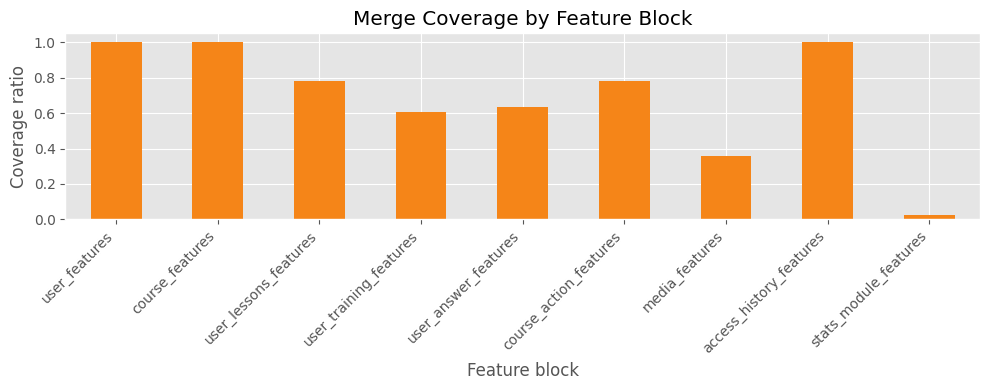

### Merge coverage report

,right_name,join_key,left_rows_before,right_rows,matched_rows,unmatched_rows,coverage_ratio,row_multiplier_delta,right_key_unique,added_columns,added_columns_mean_missing_share,left_key_unique_after
0,user_features,user_id,267206,90647,267206,0,100.00%,0,True,"sign_in_count, grade_id, timezone, wk_gender, d_wk_region_id, d_wk_municipal_id, d_wk_school_id, user_is_subscribed_flag, user_account_age_days, user_profile_age_days, user_grade_change_delay_days, user_has_grade_flag, user_has_timezone_flag, user_has_region_flag, user_has_municipal_flag, user_has_school_flag, user_has_gender_flag, user_badges_total_count, user_badges_unique_count, user_special_badges_count, user_badge_span_days, user_first_badge_at, user_last_badge_at",16.55%,True
1,course_features,course_id,267206,137,267206,0,100.00%,0,True,"course_lessons_count, course_lessons_with_tasks_count, course_lessons_with_conspect_count, course_lessons_survival_count, course_lessons_scratch_count, course_lessons_attendance_count, course_lesson_number_max, course_lessons_max_points_sum, course_lessons_task_count_sum, course_video_duration_sum, course_video_duration_mean, course_lessons_with_tasks_share, course_lessons_with_conspect_share, course_lessons_survival_share, course_lessons_scratch_share, course_lessons_attendance_share, course_task_link_count, course_unique_task_count, course_required_task_count, course_required_task_share, course_trainings_count, course_training_task_templates_sum, course_training_difficulty_mean, course_groups_count, course_groups_with_video_count, course_groups_duration_sum, course_groups_actual_duration_sum, course_groups_with_video_share, course_homeworks_count, course_unique_homework_types, course_homework_item_count, course_homework_task_item_count",17.34%,True
2,user_lessons_features,users_course_id,267206,216482,208629,58577,78.08%,0,True,"ul_lesson_rows, ul_lessons_touched_count, ul_lessons_solved_count, ul_video_visited_count, ul_video_viewed_count, ul_translation_visited_count, ul_points_sum, ul_points_mean, ul_solved_tasks_sum, ul_furthest_lesson_number, ul_task_count_gap_sum, ul_lessons_touched_ratio, ul_furthest_lesson_ratio, ul_points_ratio_vs_course, ul_solved_tasks_ratio_vs_course",31.12%,True
3,user_training_features,users_course_id,267206,161517,161517,105689,60.45%,0,True,"training_records_count, training_unique_count, training_unique_lessons_count, training_started_count, training_checked_count, training_finished_count, training_attempts_sum, training_attempts_mean, training_attempts_max, training_submitted_answers_sum, training_solved_tasks_sum, training_earned_points_sum, training_mark_mean, training_mark_max, training_high_mark_count, training_first_activity_at, training_last_activity_at, training_max_lesson_number, training_activity_span_days",42.76%,True
4,user_answer_features,users_course_id,267206,170022,170022,97184,63.63%,0,True,"answer_total_count, answer_task_unique_count, answer_resource_unique_count, answer_solved_count, answer_unsolved_count, answer_skipped_count, answer_partial_count, answer_attempts_sum, answer_attempts_mean, answer_attempts_max, answer_points_sum, answer_points_mean, answer_points_max, answer_first_at, answer_last_at, answer_active_days, answer_async_pending_count, answer_async_failed_count, answer_homework_count, answer_lesson_count, answer_training_count, answer_activity_span_days",36.46%,True
5,course_action_features,users_course_id,267206,216342,208519,58687,78.04%,0,True,"action_total_count, action_unique_types_count, action_unique_lessons_count, action_active_days, action_first_at, action_last_at, action_first_14d_count, action_first_30d_count, action_last_14d_count, action_type_count_scratch_playground_visited, action_type_count_start_training, action_type_count_user_answer, action_type_count_visit_preparation_material, action_type_count_visit_translation, action_type_count_visit_video, action_span_days, action_per_active_day",21.96%,True
6,media_features,users_course_id,267206,95249,95

### Merge integrity summary

,metric,value
0,final_rows_before_time_features,267206
1,final_columns_before_time_features,256
2,users_course_id_unique_after_merge,True
3,max_row_multiplier_delta,0
4,min_merge_coverage_ratio,0.025119


In [ ]:
final_user_course_features_AGENT, merge_report_df = assemble_master_user_course_table(
    users_courses_base_AGENT,
    user_features_AGENT,
    course_features_AGENT,
    user_lessons_agg_AGENT,
    user_trainings_agg_AGENT,
    user_answers_agg_AGENT,
    course_actions_agg_AGENT,
    media_sessions_agg_AGENT,
    access_history_agg_AGENT,
    stats_module_features_AGENT,
)

merge_report_view = merge_report_df[
    [
        "right_name",
        "join_key",
        "left_rows_before",
        "right_rows",
        "matched_rows",
        "unmatched_rows",
        "coverage_ratio",
        "row_multiplier_delta",
        "right_key_unique",
        "added_columns",
        "added_columns_mean_missing_share",
        "left_key_unique_after",
    ]
].copy()

fig, ax = plt.subplots(figsize=(10, 4))
merge_report_df.plot.bar(x="right_name", y="coverage_ratio", ax=ax, legend=False, color="#F58518")
ax.set_title("Merge Coverage by Feature Block")
ax.set_xlabel("Feature block")
ax.set_ylabel("Coverage ratio")
plt.xticks(rotation=45, ha="right")
savefig("merge_coverage_by_block_AGENT.png")
plt.show()

display(Markdown("### Merge coverage report"))
display(
    merge_report_view.style.format({
        "coverage_ratio": "{:.2%}",
        "added_columns_mean_missing_share": "{:.2%}",
    })
)

merge_integrity_summary = pd.DataFrame(
    {
        "metric": [
            "final_rows_before_time_features",
            "final_columns_before_time_features",
            "users_course_id_unique_after_merge",
            "max_row_multiplier_delta",
            "min_merge_coverage_ratio",
        ],
        "value": [
            len(final_user_course_features_AGENT),
            final_user_course_features_AGENT.shape[1],
            final_user_course_features_AGENT[CORE_ENTITY_KEY].is_unique,
            merge_report_df["row_multiplier_delta"].max(),
            round(merge_report_df["coverage_ratio"].min(), 6),
        ],
    }
)

display(Markdown("### Merge integrity summary"))
display(merge_integrity_summary)

# 17. Time-aware feature engineering

Why this step is needed:
Many business-relevant signals are not just about activity volume, but about delay, recency, inactivity, and early versus late engagement.

What problem it solves:
It turns timestamps already aligned at user-course grain into interpretable time-window features.

Input data:
The assembled master table and the notebook reference timestamp.

Expected output:
The final user-course master table with second-stage time-aware features.

How it helps the final master table:
It makes the dataset ready for later risk modeling and hypothesis testing about behavioral decline without building the target now.

In [ ]:
final_user_course_features_AGENT, time_feature_list, time_feature_summary = build_time_window_features(
    final_user_course_features_AGENT,
    reference_timestamp,
)
block_summaries.append(time_feature_summary)

display(Markdown("### Time-aware feature block summary"))
display(summary_frame(time_feature_summary))

display(Markdown("### Key check after time-aware features"))
display(build_key_diagnostics(final_user_course_features_AGENT, [[CORE_ENTITY_KEY]]))

### Time-aware feature block summary

,block_name,source_tables,target_level,rows,cols,key_cols,is_key_unique,feature_count,new_feature_count,coverage_notes,important_warnings
0,time_window_features,[final_master_user_course_features],users_course_id,267206,279,[users_course_id],True,23,23,Time-aware features are computed only after all blocks are aligned to the same user-course grain.,Observed-window features use access end as the default horizon and should be revisited if the modeling cutoff changes.


### Key check after time-aware features

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],267206,267206,267206,0,True


## Block Summary: `time_window_features`

- Source tables used: the assembled `final_user_course_features_AGENT` before second-stage timing features
- Aggregation target level: `users_course_id`
- Aggregation keys: no new merge key; features are computed row-wise on the final aligned table
- Produced features: `time_*` observed-window, delay, recency, inactivity-gap, intensity, and early-vs-late activity features
- Semantic meaning of features: the block turns already aligned timestamps into interpretable temporal behavior descriptors
- Merge / aggregation path: `assembled user-course master table -> row-wise time feature derivation -> updated final_user_course_features_AGENT`

# 18. Final master-table review

Why this step is needed:
The final dataset must be audited before export.

What problem it solves:
It verifies the final grain, reviews missingness, checks feature-family balance, and visualizes several core numeric signals.

Input data:
The fully assembled user-course master table.

Expected output:
A final quality review with integrity checks, missingness review, and compact visual diagnostics.

How it helps the final master table:
It confirms that the dataset is ready for further EDA, later target attachment, and future model training.

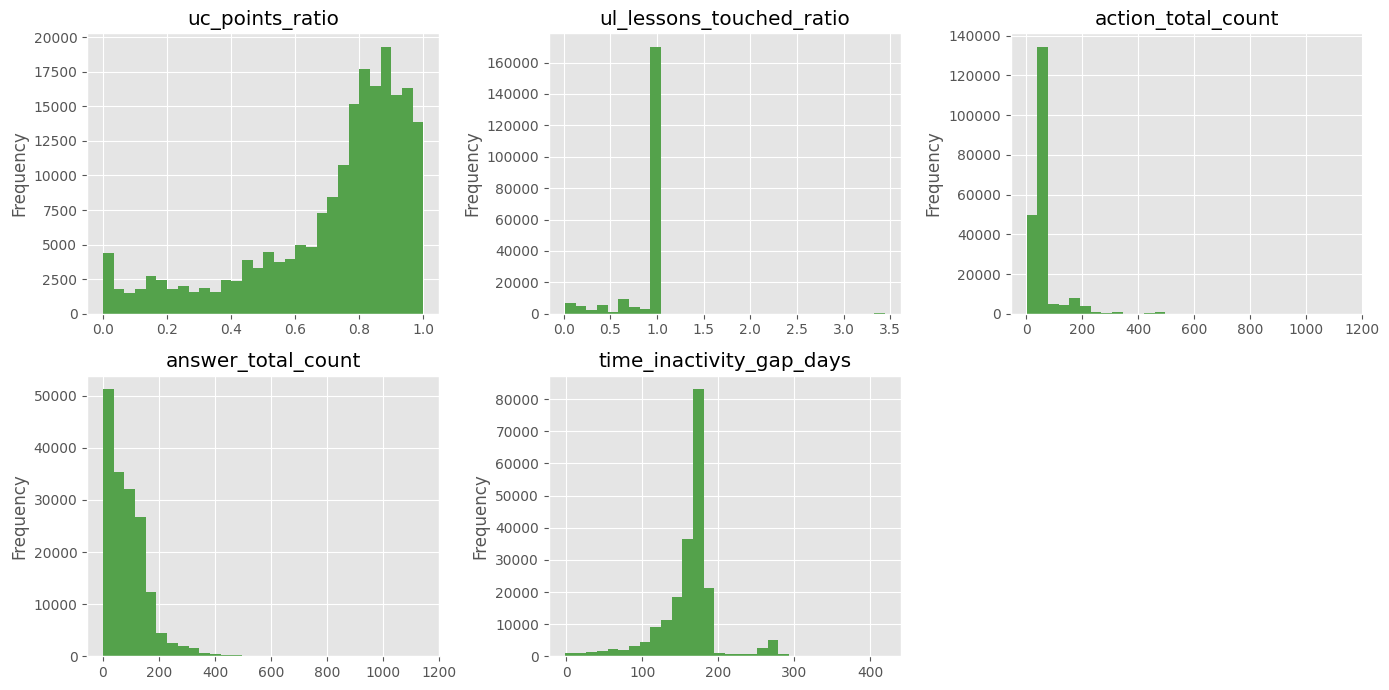

### Final key check

,key_cols,rows,non_null_rows,unique_key_rows,duplicate_rows,is_unique
0,[users_course_id],267206,267206,267206,0,True


### Feature-family summary

,feature_family,columns_count,mean_missing_share
10,stats,73,99.18%
3,course,37,19.05%
11,time,23,30.64%
2,answer,22,36.46%
13,training,19,42.76%
1,action,17,21.96%
17,user,17,10.25%
7,media,16,64.35%
15,ul,15,31.12%
14,uc,13,14.99%


### Top missing features

,column_name,missing_count,missing_share,dtype
0,training_max_lesson_number,267206,100.00%,Float64
1,uc_completion_delay_days,266852,99.87%,float64
2,wk_course_completed_at,266852,99.87%,datetime64[ns]
3,user_grade_change_delay_days,266723,99.82%,float64
4,stats_m3_interim_assessment_score,265499,99.36%,Float64
5,stats_m3_interim_assessment_submitted_at_msk,265499,99.36%,datetime64[ns]
6,stats_m2_interim_assessment_score,265421,99.33%,Float64
7,stats_m2_interim_assessment_submitted_at_msk,265421,99.33%,datetime64[ns]
8,stats_m3_all_required_final_tasks_solved_flag,265421,99.33%,float64
9,stats_m3_all_required_final_tasks_solved_negative_flag,265421,99.33%,float64


In [ ]:
final_key_check = build_key_diagnostics(final_user_course_features_AGENT, [[CORE_ENTITY_KEY]])
final_missingness = build_missingness_summary(final_user_course_features_AGENT)
feature_registry = pd.DataFrame({
    "column_name": final_user_course_features_AGENT.columns,
    "dtype": final_user_course_features_AGENT.dtypes.astype(str).values,
    "missing_share": final_user_course_features_AGENT.isna().mean().round(6).values,
})
feature_registry["feature_family"] = feature_registry["column_name"].str.split("_").str[0]
feature_family_summary = feature_registry.groupby("feature_family", as_index=False).agg(
    columns_count=("column_name", "count"),
    mean_missing_share=("missing_share", "mean"),
)

selected_numeric = [
    "uc_points_ratio",
    "ul_lessons_touched_ratio",
    "action_total_count",
    "answer_total_count",
    "time_inactivity_gap_days",
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for axis, column in zip(axes, selected_numeric):
    final_user_course_features_AGENT[column].dropna().plot.hist(bins=30, ax=axis, color="#54A24B")
    axis.set_title(column)
for axis in axes[len(selected_numeric):]:
    axis.axis("off")
savefig("final_selected_feature_distributions_AGENT.png")
plt.show()

display(Markdown("### Final key check"))
display(final_key_check)

display(Markdown("### Feature-family summary"))
display(feature_family_summary.sort_values("columns_count", ascending=False).style.format({
    "mean_missing_share": "{:.2%}",
}))

display(Markdown("### Top missing features"))
display(final_missingness.head(20).style.format({
    "missing_share": "{:.2%}",
}))

# 18.1 Semantic description of the master table

Why this step is needed:
The flat analytical table should be readable not only as a matrix of columns, but also as a documented representation of the final user-course entity.

What problem it solves:
It makes the primary key, feature groups, and the semantic meaning of each feature explicit before export.

Input data:
The fully assembled user-course master table and the feature blocks created earlier in the notebook.

Expected output:
A master-table overview, feature-group summary, and a semantic registry covering all columns in the final flat table.

How it helps the final master table:
It turns the master table into a transparent artifact that can be reused for further EDA, later target attachment, and future modeling.

In [ ]:
base_entity_columns = [
    "users_course_id", "user_id", "course_id", "state", "created_at", "updated_at", "access_finished_at",
    "wk_points", "wk_max_points", "wk_max_viewable_lessons", "wk_max_task_count",
    "wk_officially_started_at", "wk_course_completed_at",
]
user_context_columns = [
    "sign_in_count", "grade_id", "timezone", "wk_gender", "d_wk_region_id",
    "d_wk_municipal_id", "d_wk_school_id",
]
explicit_semantics = {
    "users_course_id": "Stable identifier of one pupil-course enrollment row; this is the primary key of the flat master table.",
    "user_id": "Identifier of the pupil account linked to the enrollment row.",
    "course_id": "Identifier of the course linked to the enrollment row.",
    "state": "Administrative state of the enrollment row in `users_courses`.",
    "created_at": "Timestamp when the user-course enrollment record was created.",
    "updated_at": "Timestamp of the latest administrative update of the enrollment record.",
    "access_finished_at": "Timestamp when access to the course ended according to the enrollment record.",
    "wk_points": "Observed number of points accumulated in the course according to the enrollment record.",
    "wk_max_points": "Maximum number of points available in the course according to the enrollment record.",
    "wk_max_viewable_lessons": "Maximum number of lessons that could be viewed in the course for this enrollment.",
    "wk_max_task_count": "Maximum number of tasks available in the course for this enrollment.",
    "wk_officially_started_at": "Timestamp of the official course start for this enrollment, when available.",
    "wk_course_completed_at": "Timestamp of recorded course completion for this enrollment, when available.",
    "sign_in_count": "Raw sign-in count stored on the pupil profile.",
    "grade_id": "Current grade identifier stored on the pupil profile.",
    "timezone": "Timezone value stored on the pupil profile.",
    "wk_gender": "Gender attribute stored on the pupil profile.",
    "d_wk_region_id": "Region identifier linked to the pupil profile.",
    "d_wk_municipal_id": "Municipality identifier linked to the pupil profile.",
    "d_wk_school_id": "School identifier linked to the pupil profile.",
    "course_lessons_count_x": "Course-level count of lessons from the structure block, merged directly by `course_id`.",
    "course_lesson_number_max_x": "Maximum lesson number from the course structure block, merged directly by `course_id`.",
    "course_lessons_max_points_sum_x": "Total lesson-level max points from the course structure block, merged directly by `course_id`.",
    "course_lessons_task_count_sum_x": "Total lesson-level task count from the course structure block, merged directly by `course_id`.",
    "course_lessons_count_y": "Course lesson count reused inside the user-lesson block as the denominator for progress ratios.",
    "course_lesson_number_max_y": "Maximum lesson number reused inside the user-lesson block to derive furthest-lesson ratios.",
    "course_lessons_max_points_sum_y": "Course max-points total reused inside the user-lesson block to normalize lesson points.",
    "course_lessons_task_count_sum_y": "Course task-count total reused inside the user-lesson block to normalize solved-task counts.",
    "user_first_badge_at": "Timestamp of the first observed badge assigned to the pupil.",
    "user_last_badge_at": "Timestamp of the last observed badge assigned to the pupil.",
    "training_first_activity_at": "Earliest timestamp across training start, finish, or mark-save events for the user-course.",
    "training_last_activity_at": "Latest timestamp across training start, finish, or mark-save events for the user-course.",
    "answer_first_at": "Timestamp of the first resolved answer event for the user-course.",
    "answer_last_at": "Timestamp of the last resolved answer event for the user-course.",
    "action_first_at": "Timestamp of the first action recorded in `wk_users_courses_actions` for the user-course.",
    "action_last_at": "Timestamp of the last action recorded in `wk_users_courses_actions` for the user-course.",
    "media_first_at": "Timestamp of the first resolved media session for the user-course.",
    "media_last_at": "Timestamp of the last resolved media session for the user-course.",
    "access_first_start_at": "Timestamp of the first access period start for the user-course.",
    "access_last_end_at": "Timestamp of the last access period end for the user-course.",
    "time_first_any_activity_at": "Earliest timestamp across resolved action, answer, training, and media channels.",
    "time_last_any_activity_at": "Latest timestamp across resolved action, answer, training, and media channels.",
}
feature_group_descriptions = {
    "Base entity fields": "Enrollment-level administrative fields and base user-course features derived directly from `users_courses`.",
    "User-level features": "Pupil profile, geography, subscription, and badge-history enrichment aggregated to one row per `user_id`.",
    "Course-level features": "Stable structural context of the course derived once at `course_id` level from lessons and related metadata.",
    "Lesson-progress features": "Direct lesson-touch, lesson-progress, and lesson-based point accumulation signals aggregated by `users_course_id`.",
    "Training features": "Training-attempt intensity, mark, and progression signals resolved through training -> lesson -> course linkage.",
    "Answer features": "Resolved answer-event behavior across lesson, training, and homework resources, aggregated by `users_course_id`.",
    "Action-log features": "Course action intensity, diversity, and simple temporal-window features from `wk_users_courses_actions`.",
    "Media features": "Viewing-session volume and completion signals derived from lesson and group media sessions.",
    "Access-history features": "Administrative access-period and extension or revoke context aggregated directly at `users_course_id` level.",
    "Stats module features": "Module-level status, assessment, reflection, and activity indicators resolved from `stats__module_*` tables.",
    "Time-derived features": "Second-stage delays, recency, inactivity gaps, and observed-window intensity features built after assembly.",
    "Other features": "Columns that do not fit the predefined semantic groups but remain part of the flat analytical table.",
}
feature_group_order = list(feature_group_descriptions)

def classify_feature_group(column_name: str) -> str:
    if column_name in base_entity_columns or column_name.startswith("uc_"):
        return "Base entity fields"
    if column_name in user_context_columns or column_name.startswith("user_"):
        return "User-level features"
    if column_name.startswith("course_"):
        return "Course-level features"
    if column_name.startswith("ul_"):
        return "Lesson-progress features"
    if column_name.startswith("training_"):
        return "Training features"
    if column_name.startswith("answer_"):
        return "Answer features"
    if column_name.startswith("action_"):
        return "Action-log features"
    if column_name.startswith("media_"):
        return "Media features"
    if column_name.startswith("access_"):
        return "Access-history features"
    if column_name.startswith("stats_m"):
        return "Stats module features"
    if column_name.startswith("time_"):
        return "Time-derived features"
    return "Other features"

def humanize(name: str) -> str:
    repl = {"uc": "user course", "ul": "user lesson", "pct": "percent", "nunique": "distinct count", "msk": "MSK", "vod": "video on demand"}
    return " ".join(repl.get(token, token) for token in name.split("_"))

def describe_stats_feature(column_name: str) -> str:
    parts = column_name.split("_", 2)
    module_name = f"module {parts[1][1:]}"
    remainder = parts[2]
    if remainder == "row_count":
        return f"Count of raw rows contributed by {module_name} to the user-course record."
    if remainder.endswith("_negative_flag"):
        return f"Binary indicator that the {module_name} outcome for {humanize(remainder[:-14])} was negative, failed, or explicitly not completed."
    if remainder.endswith("_flag"):
        return f"Binary indicator that the {module_name} outcome for {humanize(remainder[:-5])} was positive, present, or completed."
    if remainder.endswith("_nunique"):
        return f"Number of distinct {humanize(remainder[:-8])} values observed in {module_name} for the user-course."
    if remainder.endswith("_count"):
        return f"Count of {humanize(remainder[:-6])} recorded in {module_name} for the user-course."
    if remainder.endswith("_date") or remainder.endswith("_at") or remainder.endswith("_at_msk"):
        return f"Timestamp or date recorded for {humanize(remainder)} in {module_name}."
    return f"Module-level value for {humanize(remainder)} taken from {module_name}."

def describe_feature(column_name: str, feature_group: str) -> str:
    if column_name in explicit_semantics:
        return explicit_semantics[column_name]
    if column_name.startswith("stats_m"):
        return describe_stats_feature(column_name)
    if column_name.startswith("action_type_count_"):
        return f"Count of action-log events with action type `{column_name.replace('action_type_count_', '')}` for the user-course."
    if column_name.startswith("media_kind_count_"):
        return f"Count of media sessions of kind `{column_name.replace('media_kind_count_', '')}` for the user-course."
    suffix_rules = [
        ("_negative_flag", "Binary indicator that {} is explicitly negative, missing, revoked, or not completed."),
        ("_flag", "Binary indicator that {} is present, true, or satisfied."),
        ("_share", "Share-based feature describing the proportion of {} within the relevant block."),
        ("_ratio", "Ratio feature comparing {} against its normalization context."),
        ("_count", "Count of {} aggregated within the {} block."),
        ("_sum", "Total amount of {} aggregated within the {} block."),
        ("_mean", "Average value of {} aggregated within the {} block."),
        ("_max", "Maximum value of {} aggregated within the {} block."),
        ("_min", "Minimum value of {} aggregated within the {} block."),
        ("_days", "Duration, delay, or recency in days for {}."),
        ("_at", "Timestamp feature marking {}."),
    ]
    for suffix, template in suffix_rules:
        if column_name.endswith(suffix):
            subject = humanize(column_name[: -len(suffix)])
            return template.format(subject, feature_group.lower())
    return f"Derived feature describing {humanize(column_name)} in the final user-course analytical table."

master_table_overview_df = pd.DataFrame([
    {"property": "table_represents", "value": "One row per pupil-course enrollment after enriching the base `users_courses` entity with prepared feature blocks."},
    {"property": "primary_key", "value": CORE_ENTITY_KEY},
    {"property": "why_this_grain", "value": "The business object of interest is a specific pupil on a specific course, so all downstream EDA and future targets should attach to one `users_course_id` row."},
    {"property": "merged_feature_blocks", "value": ", ".join(["users_courses_base_AGENT", "user_features_AGENT", "course_features_AGENT", "user_lessons_agg_AGENT", "user_trainings_agg_AGENT", "user_answers_agg_AGENT", "course_actions_agg_AGENT", "media_sessions_agg_AGENT", "access_history_agg_AGENT", "stats_module_features_AGENT", "time_window_features"])},
    {"property": "rows", "value": len(final_user_course_features_AGENT)},
    {"property": "columns", "value": final_user_course_features_AGENT.shape[1]},
    {"property": "primary_key_unique", "value": final_user_course_features_AGENT[CORE_ENTITY_KEY].is_unique},
])
master_feature_semantics_df = pd.DataFrame({"feature_name": final_user_course_features_AGENT.columns})
master_feature_semantics_df["feature_group"] = master_feature_semantics_df["feature_name"].map(classify_feature_group)
master_feature_semantics_df["semantic_meaning"] = master_feature_semantics_df.apply(lambda row: describe_feature(row["feature_name"], row["feature_group"]), axis=1)
master_feature_semantics_df["feature_group"] = pd.Categorical(master_feature_semantics_df["feature_group"], categories=feature_group_order, ordered=True)
master_feature_semantics_df = master_feature_semantics_df.sort_values(["feature_group", "feature_name"]).reset_index(drop=True)
feature_group_overview_df = master_feature_semantics_df.groupby("feature_group", observed=False).agg(feature_count=("feature_name", "count")).reset_index()
feature_group_overview_df["group_description"] = feature_group_overview_df["feature_group"].map(feature_group_descriptions)
feature_group_overview_df["merge_key_or_alignment"] = feature_group_overview_df["feature_group"].map({
    "Base entity fields": "seed table / users_course_id",
    "User-level features": "merge on user_id",
    "Course-level features": "merge on course_id",
    "Lesson-progress features": "merge on users_course_id",
    "Training features": "merge on users_course_id",
    "Answer features": "merge on users_course_id",
    "Action-log features": "merge on users_course_id",
    "Media features": "merge on users_course_id",
    "Access-history features": "merge on users_course_id",
    "Stats module features": "merge on users_course_id",
    "Time-derived features": "computed after final assembly on users_course_id",
    "Other features": "review case by case",
})

display(Markdown("### Master-table overview"))
display(master_table_overview_df)

display(Markdown("### Feature-group overview"))
display(feature_group_overview_df)

display(Markdown("### Full semantic registry for the final master table"))
display(master_feature_semantics_df)

### Master-table overview

,property,value
0,table_represents,One row per pupil-course enrollment after enriching the base `users_courses` entity with prepared feature blocks.
1,primary_key,users_course_id
2,why_this_grain,"The business object of interest is a specific pupil on a specific course, so all downstream EDA and future targets should attach to one `users_course_id` row."
3,merged_feature_blocks,"users_courses_base_AGENT, user_features_AGENT, course_features_AGENT, user_lessons_agg_AGENT, user_trainings_agg_AGENT, user_answers_agg_AGENT, course_actions_agg_AGENT, media_sessions_agg_AGENT, access_history_agg_AGENT, stats_module_features_AGENT, time_window_features"
4,rows,267206
5,columns,279
6,primary_key_unique,True


### Feature-group overview

,feature_group,feature_count,group_description,merge_key_or_alignment
0,Base entity fields,26,Enrollment-level administrative fields and base user-course features derived directly from `users_courses`.,seed table / users_course_id
1,User-level features,23,"Pupil profile, geography, subscription, and badge-history enrichment aggregated to one row per `user_id`.",merge on user_id
2,Course-level features,36,Stable structural context of the course derived once at `course_id` level from lessons and related metadata.,merge on course_id
3,Lesson-progress features,15,"Direct lesson-touch, lesson-progress, and lesson-based point accumulation signals aggregated by `users_course_id`.",merge on users_course_id
4,Training features,19,"Training-attempt intensity, mark, and progression signals resolved through training -> lesson -> course linkage.",merge on users_course_id
5,Answer features,22,"Resolved answer-event behavior across lesson, training, and homework resources, aggregated by `users_course_id`.",merge on users_course_id
6,Action-log features,17,"Course action intensity, diversity, and simple temporal-window features from `wk_users_courses_actions`.",merge on users_course_id
7,Media features,16,Viewing-session volume and completion signals derived from lesson and group media sessions.,merge on users_course_id
8,Access-history features,9,Administrative access-period and extension or revoke context aggregated directly at `users_course_id` level.,merge on users_course_id
9,Stats module features,73,"Module-level status, assessment, reflection, and activity indicators resolved from `stats__module_*` tables.",merge on users_course_id


### Full semantic registry for the final master table

,feature_name,feature_group,semantic_meaning
0,access_finished_at,Base entity fields,Timestamp when access to the course ended according to the enrollment record.
1,course_id,Base entity fields,Identifier of the course linked to the enrollment row.
2,created_at,Base entity fields,Timestamp when the user-course enrollment record was created.
3,state,Base entity fields,Administrative state of the enrollment row in `users_courses`.
4,uc_access_window_days,Base entity fields,"Duration, delay, or recency in days for user course access window."
5,uc_completion_delay_days,Base entity fields,"Duration, delay, or recency in days for user course completion delay."
6,uc_enrollment_age_days,Base entity fields,"Duration, delay, or recency in days for user course enrollment age."
7,uc_full_points_flag,Base entity fields,"Binary indicator that user course full points is present, true, or satisfied."
8,uc_has_access_end,Base entity fields,Derived feature describing user course has access end in the final user-course analytical table.
9,uc_has_completion_record,Base entity fields,Derived feature describing user course has completion record in the final user-course analytical table.


### Final visual pipeline schema

#### Pipeline steps summary

,flow
0,users_courses → filter pupil rows + derive base entity [users_course_id] → users_courses_base_AGENT
1,users → filter pupil rows + derive base entity [user_id] → users_courses_base_AGENT
2,lessons → aggregate by course_id [course_id] → course_features_AGENT
3,lesson_tasks → aggregate by course_id [course_id] → course_features_AGENT
4,trainings → aggregate by course_id [course_id] → course_features_AGENT
5,groups → aggregate by course_id [course_id] → course_features_AGENT
6,homeworks → aggregate by course_id [course_id] → course_features_AGENT
7,homework_items → aggregate by course_id [course_id] → course_features_AGENT
8,users → aggregate by user_id [user_id] → user_features_AGENT
9,user_award_badges → aggregate by user_id [user_id] → user_features_AGENT


#### Visual graph

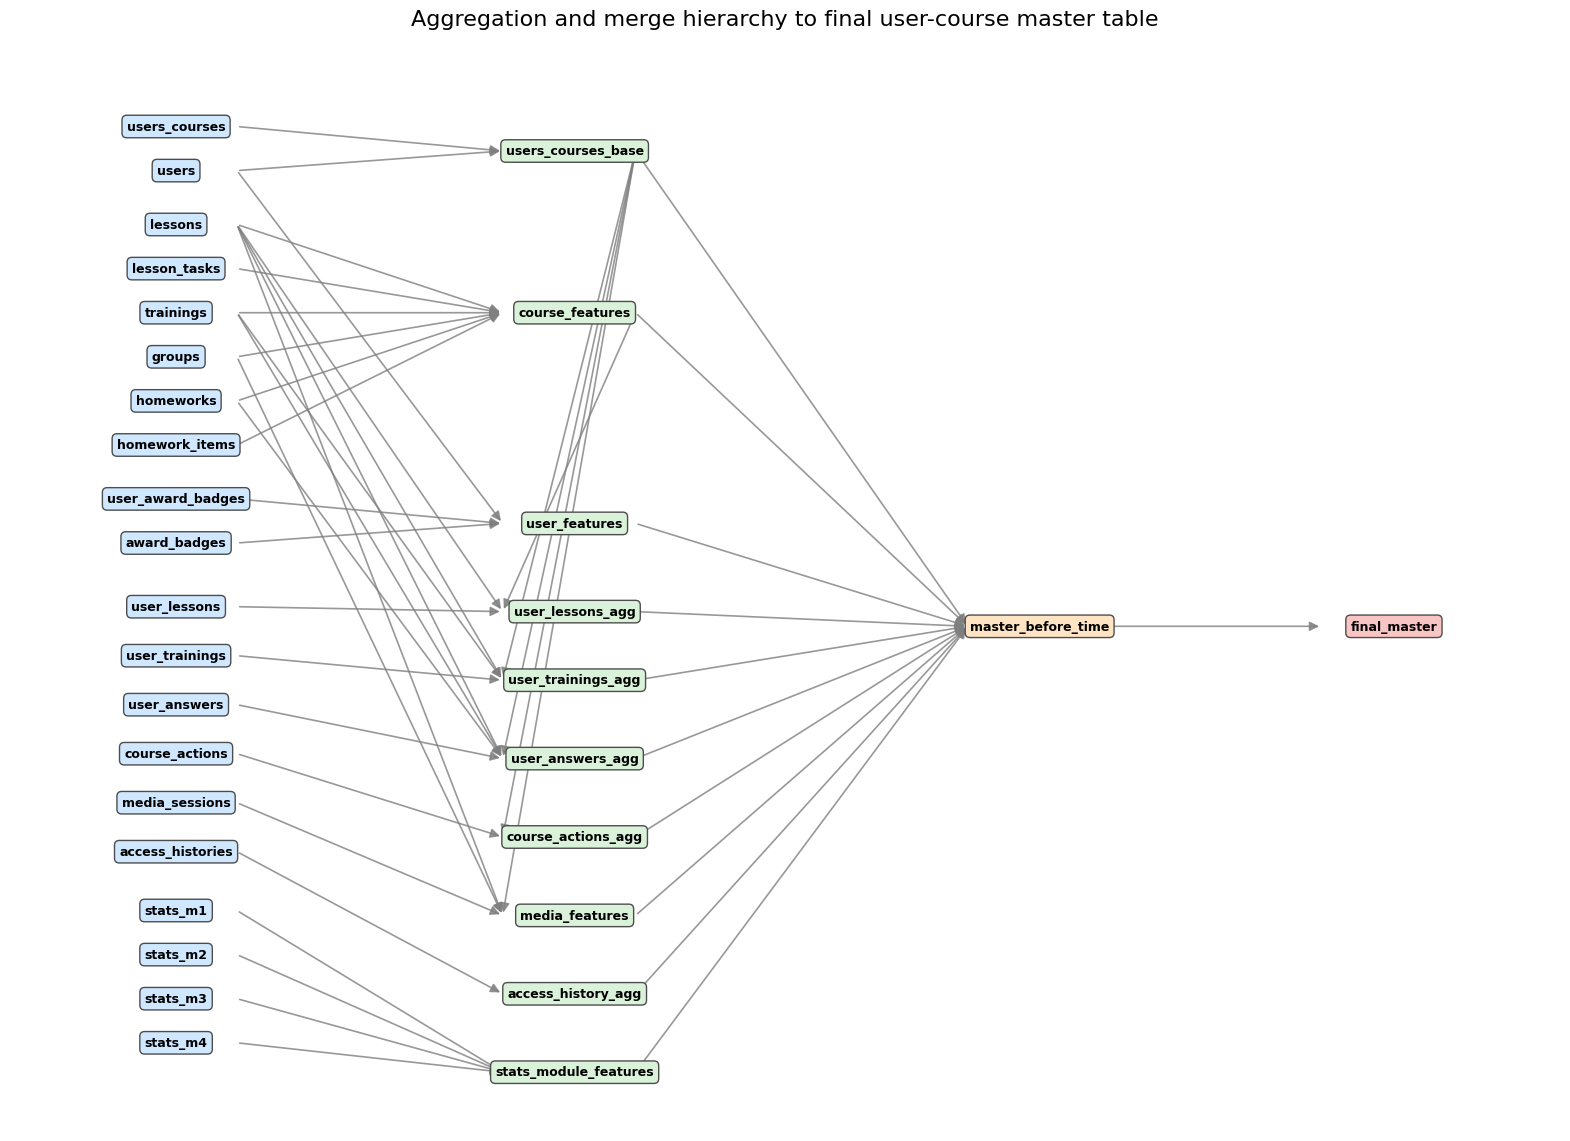

#### Edge legend (operations and keys)

,source,operation,key,output
0,user_access_histories,aggregate by users_course_id,users_course_id,access_history_agg_AGENT
1,access_history_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
2,course_actions_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
3,course_features_AGENT,merge on course_id,course_id,assembled_master_before_time
4,media_sessions_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
5,stats_module_features_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
6,user_answers_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
7,user_features_AGENT,merge on user_id,user_id,assembled_master_before_time
8,user_lessons_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time
9,user_trainings_agg_AGENT,merge on users_course_id,users_course_id,assembled_master_before_time


In [ ]:
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt

display(Markdown("### Final visual pipeline schema"))

try:
    import networkx as nx
except ImportError:
    nx = None


# -----------------------------------------------------------------------------
# 1. Pipeline steps
# -----------------------------------------------------------------------------
pipeline_steps = [
    {"source": "users_courses", "operation": "filter pupil rows + derive base entity", "key": "users_course_id", "output": "users_courses_base_AGENT"},
    {"source": "users", "operation": "filter pupil rows + derive base entity", "key": "user_id", "output": "users_courses_base_AGENT"},

    {"source": "lessons", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},
    {"source": "lesson_tasks", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},
    {"source": "trainings", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},
    {"source": "groups", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},
    {"source": "homeworks", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},
    {"source": "homework_items", "operation": "aggregate by course_id", "key": "course_id", "output": "course_features_AGENT"},

    {"source": "users", "operation": "aggregate by user_id", "key": "user_id", "output": "user_features_AGENT"},
    {"source": "user_award_badges", "operation": "aggregate by user_id", "key": "user_id", "output": "user_features_AGENT"},
    {"source": "award_badges", "operation": "aggregate by user_id", "key": "user_id", "output": "user_features_AGENT"},

    {"source": "user_lessons", "operation": "aggregate by users_course_id", "key": "users_course_id", "output": "user_lessons_agg_AGENT"},
    {"source": "lessons", "operation": "resolve lesson metadata", "key": "lesson_id", "output": "user_lessons_agg_AGENT"},
    {"source": "course_features_AGENT", "operation": "reuse denominators for ratios", "key": "course_id", "output": "user_lessons_agg_AGENT"},

    {"source": "user_trainings", "operation": "resolve users_course_id + aggregate", "key": "training_id -> lesson_id -> course_id -> users_course_id", "output": "user_trainings_agg_AGENT"},
    {"source": "trainings", "operation": "resolve users_course_id + aggregate", "key": "training_id -> lesson_id", "output": "user_trainings_agg_AGENT"},
    {"source": "lessons", "operation": "resolve users_course_id + aggregate", "key": "lesson_id -> course_id", "output": "user_trainings_agg_AGENT"},
    {"source": "users_courses_base_AGENT", "operation": "resolve users_course_id + aggregate", "key": "user_id + course_id", "output": "user_trainings_agg_AGENT"},

    {"source": "user_answers", "operation": "resolve users_course_id + aggregate", "key": "resource_id -> course_id -> users_course_id", "output": "user_answers_agg_AGENT"},
    {"source": "lessons", "operation": "resolve answer course_id", "key": "resource_id", "output": "user_answers_agg_AGENT"},
    {"source": "trainings", "operation": "resolve answer course_id", "key": "resource_id -> lesson_id", "output": "user_answers_agg_AGENT"},
    {"source": "homeworks", "operation": "resolve answer course_id", "key": "resource_id -> lesson_id", "output": "user_answers_agg_AGENT"},
    {"source": "users_courses_base_AGENT", "operation": "resolve users_course_id", "key": "user_id + course_id", "output": "user_answers_agg_AGENT"},

    {"source": "wk_users_courses_actions", "operation": "aggregate by users_course_id", "key": "users_course_id", "output": "course_actions_agg_AGENT"},
    {"source": "users_courses_base_AGENT", "operation": "attach enrollment anchors", "key": "users_course_id", "output": "course_actions_agg_AGENT"},

    {"source": "wk_media_view_sessions", "operation": "resolve users_course_id + aggregate", "key": "resource_id + viewer_id", "output": "media_sessions_agg_AGENT"},
    {"source": "groups", "operation": "resolve media course_id", "key": "resource_id -> lesson_id", "output": "media_sessions_agg_AGENT"},
    {"source": "lessons", "operation": "resolve media course_id", "key": "resource_id -> course_id", "output": "media_sessions_agg_AGENT"},
    {"source": "users_courses_base_AGENT", "operation": "resolve users_course_id", "key": "viewer_id + course_id", "output": "media_sessions_agg_AGENT"},

    {"source": "user_access_histories", "operation": "aggregate by users_course_id", "key": "users_course_id", "output": "access_history_agg_AGENT"},

    {"source": "stats__module_1", "operation": "resolve users_course_id + aggregate", "key": "user_id + course_id", "output": "stats_module_features_AGENT"},
    {"source": "stats__module_2", "operation": "resolve users_course_id + aggregate", "key": "user_id + course_id", "output": "stats_module_features_AGENT"},
    {"source": "stats__module_3", "operation": "resolve users_course_id + aggregate", "key": "user_id + course_id", "output": "stats_module_features_AGENT"},
    {"source": "stats__module_4", "operation": "resolve users_course_id + aggregate", "key": "user_id + course_id", "output": "stats_module_features_AGENT"},

    {"source": "users_courses_base_AGENT", "operation": "seed master table", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "user_features_AGENT", "operation": "merge on user_id", "key": "user_id", "output": "assembled_master_before_time"},
    {"source": "course_features_AGENT", "operation": "merge on course_id", "key": "course_id", "output": "assembled_master_before_time"},
    {"source": "user_lessons_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "user_trainings_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "user_answers_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "course_actions_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "media_sessions_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "access_history_agg_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},
    {"source": "stats_module_features_AGENT", "operation": "merge on users_course_id", "key": "users_course_id", "output": "assembled_master_before_time"},

    {"source": "assembled_master_before_time", "operation": "derive time-aware features", "key": "users_course_id", "output": "final_user_course_features_AGENT"},
]

pipeline_graph_df = pd.DataFrame(pipeline_steps)

# -----------------------------------------------------------------------------
# 2. Compact display table
# -----------------------------------------------------------------------------
display(Markdown("#### Pipeline steps summary"))

pretty_df = pipeline_graph_df.copy()
pretty_df["flow"] = (
    pretty_df["source"]
    + "  →  "
    + pretty_df["operation"]
    + "  ["
    + pretty_df["key"]
    + "]  →  "
    + pretty_df["output"]
)

display(pretty_df[["flow"]])


# -----------------------------------------------------------------------------
# 3. Short labels for graph nodes
# -----------------------------------------------------------------------------
label_map = {
    "users_courses": "users_courses",
    "users": "users",
    "lessons": "lessons",
    "lesson_tasks": "lesson_tasks",
    "trainings": "trainings",
    "groups": "groups",
    "homeworks": "homeworks",
    "homework_items": "homework_items",
    "user_award_badges": "user_award_badges",
    "award_badges": "award_badges",
    "user_lessons": "user_lessons",
    "user_trainings": "user_trainings",
    "user_answers": "user_answers",
    "wk_users_courses_actions": "course_actions",
    "wk_media_view_sessions": "media_sessions",
    "user_access_histories": "access_histories",
    "stats__module_1": "stats_m1",
    "stats__module_2": "stats_m2",
    "stats__module_3": "stats_m3",
    "stats__module_4": "stats_m4",

    "users_courses_base_AGENT": "users_courses_base",
    "course_features_AGENT": "course_features",
    "user_features_AGENT": "user_features",
    "user_lessons_agg_AGENT": "user_lessons_agg",
    "user_trainings_agg_AGENT": "user_trainings_agg",
    "user_answers_agg_AGENT": "user_answers_agg",
    "course_actions_agg_AGENT": "course_actions_agg",
    "media_sessions_agg_AGENT": "media_features",
    "access_history_agg_AGENT": "access_history_agg",
    "stats_module_features_AGENT": "stats_module_features",
    "assembled_master_before_time": "master_before_time",
    "final_user_course_features_AGENT": "final_master",
}

raw_nodes = [
    "users_courses", "users", "lessons", "lesson_tasks", "trainings", "groups", "homeworks", "homework_items",
    "user_award_badges", "award_badges", "user_lessons", "user_trainings", "user_answers",
    "wk_users_courses_actions", "wk_media_view_sessions", "user_access_histories",
    "stats__module_1", "stats__module_2", "stats__module_3", "stats__module_4",
]

block_nodes = [
    "users_courses_base_AGENT", "course_features_AGENT", "user_features_AGENT", "user_lessons_agg_AGENT",
    "user_trainings_agg_AGENT", "user_answers_agg_AGENT", "course_actions_agg_AGENT",
    "media_sessions_agg_AGENT", "access_history_agg_AGENT", "stats_module_features_AGENT",
    "assembled_master_before_time", "final_user_course_features_AGENT",
]

# -----------------------------------------------------------------------------
# 4. More spacious layout
# -----------------------------------------------------------------------------
node_positions = {
    "users_courses": (0.0, 13.0),
    "users": (0.0, 12.1),
    "lessons": (0.0, 11.0),
    "lesson_tasks": (0.0, 10.1),
    "trainings": (0.0, 9.2),
    "groups": (0.0, 8.3),
    "homeworks": (0.0, 7.4),
    "homework_items": (0.0, 6.5),
    "user_award_badges": (0.0, 5.4),
    "award_badges": (0.0, 4.5),
    "user_lessons": (0.0, 3.2),
    "user_trainings": (0.0, 2.2),
    "user_answers": (0.0, 1.2),
    "wk_users_courses_actions": (0.0, 0.2),
    "wk_media_view_sessions": (0.0, -0.8),
    "user_access_histories": (0.0, -1.8),
    "stats__module_1": (0.0, -3.0),
    "stats__module_2": (0.0, -3.9),
    "stats__module_3": (0.0, -4.8),
    "stats__module_4": (0.0, -5.7),

    "users_courses_base_AGENT": (3.6, 12.5),
    "course_features_AGENT": (3.6, 9.2),
    "user_features_AGENT": (3.6, 4.9),
    "user_lessons_agg_AGENT": (3.6, 3.1),
    "user_trainings_agg_AGENT": (3.6, 1.7),
    "user_answers_agg_AGENT": (3.6, 0.1),
    "course_actions_agg_AGENT": (3.6, -1.5),
    "media_sessions_agg_AGENT": (3.6, -3.1),
    "access_history_agg_AGENT": (3.6, -4.7),
    "stats_module_features_AGENT": (3.6, -6.3),

    "assembled_master_before_time": (7.8, 2.8),
    "final_user_course_features_AGENT": (11.0, 2.8),
}

node_colors = {
    **{node: "#cfe8ff" for node in raw_nodes},
    **{node: "#d9f2d9" for node in block_nodes[:-2]},
    "assembled_master_before_time": "#ffe4c4",
    "final_user_course_features_AGENT": "#f8c4c4",
}

# -----------------------------------------------------------------------------
# 5. Draw simplified graph WITHOUT edge labels
# -----------------------------------------------------------------------------
display(Markdown("#### Visual graph"))

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_title("Aggregation and merge hierarchy to final user-course master table", fontsize=16, pad=20)
ax.axis("off")

if nx is not None:
    graph = nx.DiGraph()

    for node in raw_nodes + block_nodes:
        graph.add_node(node)

    for _, row in pipeline_graph_df.iterrows():
        graph.add_edge(row["source"], row["output"])

    nx.draw_networkx_nodes(
        graph,
        pos=node_positions,
        nodelist=raw_nodes,
        node_color=[node_colors[node] for node in raw_nodes],
        node_size=2600,
        linewidths=1.0,
        edgecolors="#4d4d4d",
        ax=ax,
    )
    nx.draw_networkx_nodes(
        graph,
        pos=node_positions,
        nodelist=block_nodes,
        node_color=[node_colors[node] for node in block_nodes],
        node_size=3300,
        linewidths=1.2,
        edgecolors="#4d4d4d",
        ax=ax,
    )

    nx.draw_networkx_labels(
        graph,
        pos=node_positions,
        labels=label_map,
        font_size=9,
        font_weight="bold",
        ax=ax,
    )

    nx.draw_networkx_edges(
        graph,
        pos=node_positions,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.2,
        edge_color="#7f7f7f",
        alpha=0.8,
        ax=ax,
    )

else:
    from matplotlib.patches import FancyArrowPatch

    for node, (x_coord, y_coord) in node_positions.items():
        bbox = dict(
            boxstyle="round,pad=0.38",
            facecolor=node_colors[node],
            edgecolor="#4d4d4d",
            linewidth=1.0,
        )
        ax.text(
            x_coord,
            y_coord,
            label_map[node],
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=bbox,
        )

    drawn_edges = set()
    for _, row in pipeline_graph_df.iterrows():
        source, output = row["source"], row["output"]
        if (source, output) in drawn_edges:
            continue
        drawn_edges.add((source, output))

        x1, y1 = node_positions[source]
        x2, y2 = node_positions[output]
        arrow = FancyArrowPatch(
            (x1 + 0.55, y1),
            (x2 - 0.65, y2),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.2,
            color="#7f7f7f",
            alpha=0.8,
            connectionstyle="arc3,rad=0.0",
        )
        ax.add_patch(arrow)

    ax.set_xlim(-1.5, 12.5)
    ax.set_ylim(-7.5, 14.5)

plt.show()


# -----------------------------------------------------------------------------
# 6. Separate legend table for edges
# -----------------------------------------------------------------------------
display(Markdown("#### Edge legend (operations and keys)"))

legend_df = (
    pipeline_graph_df[["source", "operation", "key", "output"]]
    .drop_duplicates()
    .sort_values(["output", "source", "operation"])
    .reset_index(drop=True)
)

display(legend_df)

# 19. Export of artifacts

Why this step is needed:
The notebook must leave behind reusable artifacts for later analysis and modeling.

What problem it solves:
It saves the final table, intermediate blocks, route diagnostics, merge diagnostics, missingness review, semantic summaries, and the aggregation schema under `data/AGENT`.

Input data:
All prepared blocks, the final master table, and the notebook diagnostics.

Expected output:
CSV summaries, feature blocks, figures, and the final master table with `_AGENT` suffixes.

How it helps the final master table:
It makes the enriched user-course feature pipeline reproducible and ready for downstream work without touching raw files or the original `EDA.ipynb`.

In [ ]:
block_summary_df = pd.DataFrame(block_summaries)

exports = {
    # BLOCK_EXPORT_NAMES["users_courses_base"]: users_courses_base_AGENT,
    # BLOCK_EXPORT_NAMES["user_features"]: user_features_AGENT,
    # BLOCK_EXPORT_NAMES["course_features"]: course_features_AGENT,
    # BLOCK_EXPORT_NAMES["user_lessons"]: user_lessons_agg_AGENT,
    # BLOCK_EXPORT_NAMES["user_trainings"]: user_trainings_agg_AGENT,
    # BLOCK_EXPORT_NAMES["user_answers"]: user_answers_agg_AGENT,
    # BLOCK_EXPORT_NAMES["course_actions"]: course_actions_agg_AGENT,
    # BLOCK_EXPORT_NAMES["media"]: media_sessions_agg_AGENT,
    # BLOCK_EXPORT_NAMES["access"]: access_history_agg_AGENT,
    # BLOCK_EXPORT_NAMES["stats"]: stats_module_features_AGENT,
    BLOCK_EXPORT_NAMES["final_master"]: final_user_course_features,
}

for export_name, export_df in exports.items():
    save_dataframe(export_df, export_name)

# save_summary(tables_overview, "tables_overview_AGENT")
# save_summary(id_cleaning_summary, "id_cleaning_summary_AGENT")
# save_summary(drop_summary, "drop_service_summary_AGENT")
# save_summary(entity_key_diagnostics, "entity_key_diagnostics_AGENT")
# save_summary(direct_link_diagnostics, "direct_link_diagnostics_AGENT")
# save_summary(stats_raw_key_diagnostics, "stats_raw_key_diagnostics_AGENT")
# save_summary(stats_raw_missing_overview, "stats_raw_missing_overview_AGENT")
# save_summary(stats_route_diagnostics, "stats_route_diagnostics_AGENT")
# save_summary(block_summary_df, "block_summaries_AGENT")
# save_summary(merge_report_df, "merge_report_AGENT")
# save_summary(pipeline_schema_df, "pipeline_schema_AGENT")
# save_summary(master_table_overview_df, "master_table_overview_AGENT")
# save_summary(feature_group_overview_df, "feature_group_overview_AGENT")
# save_summary(master_feature_semantics_df, "master_feature_semantics_AGENT")
# save_summary(final_missingness, "final_missingness_AGENT")
# save_summary(feature_registry, "feature_registry_AGENT")
# save_summary(feature_family_summary, "feature_family_summary_AGENT")

display(
    summary_frame(
        {
            "final_rows": len(final_user_course_features_AGENT),
            "final_columns": final_user_course_features_AGENT.shape[1],
            "final_key_is_unique": final_user_course_features_AGENT[CORE_ENTITY_KEY].is_unique,
            "exports_saved_to": str(TABLES_DIR),
        }
    )
)

,final_rows,final_columns,final_key_is_unique,exports_saved_to
0,267206,279,True,C:\Repos\Xakaton\data\AGENT\tables
